# Tema 4 - El Transistor Bipolar de Unión (BJT)

**Fundamentos de Electrónica - 2º GIERM**

---

## Objetivos de aprendizaje

- Comprender la estructura física y el funcionamiento del transistor BJT (NPN y PNP)
- Dominar todas las fórmulas fundamentales y saber cuándo aplicar cada una
- Interpretar las curvas características de entrada y salida
- Conocer los modelos de Ebers-Moll y los modelos linealizados de gran señal
- Aplicar una metodología sistemática para resolver circuitos con transistores
- Resolver ejercicios de polarización tanto para transistores NPN como PNP

In [1]:
!pip install schemdraw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'
COLOR_RECTA = '#cb181d'
COLOR_PUNTO = '#238b45'
COLOR_N = '#a6cee3'
COLOR_P = '#b2df8a'

print('Configuración lista.')

Configuración lista.


---
## 1. Introducción: ¿Qué es un transistor BJT?

El **Transistor Bipolar de Unión** (BJT, del inglés *Bipolar Junction Transistor*) es un dispositivo semiconductor formado por **dos uniones pn**, que funciona como una **fuente de corriente dependiente de corriente**.

Si un **diodo** es como una **válvula antirretorno**, el **transistor** es como un **grifo**: el caudal de agua ($I_C$) se controla girando la llave ($I_B$). Una señal pequeña controla un flujo grande.

### 1.1 Estructura del BJT: NPN y PNP

Existen dos tipos según el orden de las capas semiconductoras:
- **NPN**: capas N - P - N (el más común)
- **PNP**: capas P - N - P

Tres terminales: **Emisor (E)**, **Base (B)** (capa estrecha intermedia) y **Colector (C)**.

Dos uniones pn: **Unión de Emisor (UE)** y **Unión de Colector (UC)**.

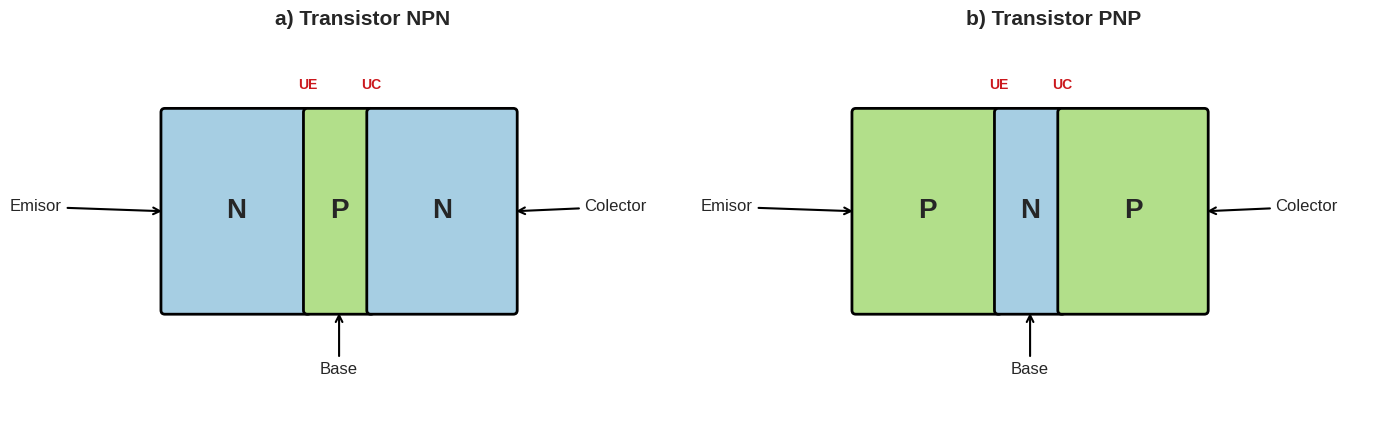

In [2]:
# Diagrama de estructura NPN y PNP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def dibujar_estructura(ax, tipo, titulo):
    ax.set_xlim(-1, 7); ax.set_ylim(-1, 4); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(titulo, fontsize=15, fontweight='bold')
    if tipo == 'NPN':
        colores, etiquetas = [COLOR_N, COLOR_P, COLOR_N], ['N', 'P', 'N']
    else:
        colores, etiquetas = [COLOR_P, COLOR_N, COLOR_P], ['P', 'N', 'P']
    for x, w, c, e in zip([0.5, 2.3, 3.1], [1.8, 0.8, 1.8], colores, etiquetas):
        ax.add_patch(FancyBboxPatch((x, 0.5), w, 2.5, boxstyle='round,pad=0.05',
                                    facecolor=c, edgecolor='black', linewidth=2))
        ax.text(x + w/2, 1.75, e, ha='center', va='center', fontsize=20, fontweight='bold')
    ax.annotate('Emisor', xy=(0.5, 1.75), xytext=(-0.8, 1.75), fontsize=12, ha='right',
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('Colector', xy=(4.9, 1.75), xytext=(5.8, 1.75), fontsize=12, ha='left',
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('Base', xy=(2.7, 0.5), xytext=(2.7, -0.3), fontsize=12, ha='center',
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.text(2.3, 3.3, 'UE', ha='center', fontsize=10, color=COLOR_RECTA, fontweight='bold')
    ax.text(3.1, 3.3, 'UC', ha='center', fontsize=10, color=COLOR_RECTA, fontweight='bold')

dibujar_estructura(axes[0], 'NPN', 'a) Transistor NPN')
dibujar_estructura(axes[1], 'PNP', 'b) Transistor PNP')
plt.tight_layout()
plt.show()

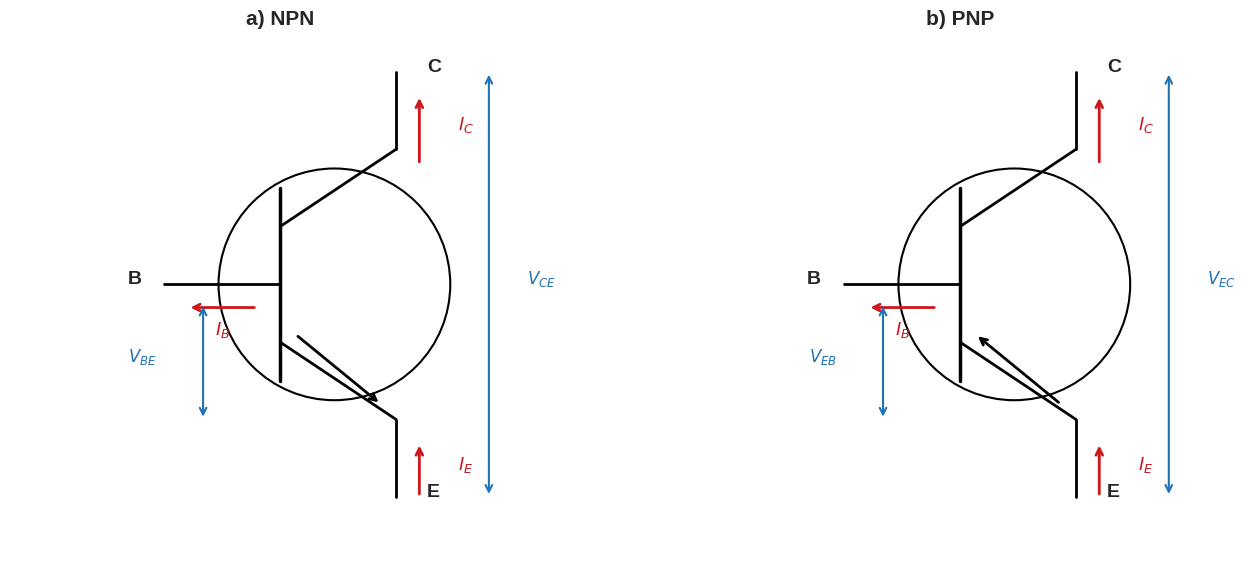

In [3]:
# Símbolos eléctricos NPN y PNP
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def dibujar_simbolo(ax, tipo):
    ax.set_xlim(-2, 5); ax.set_ylim(-1, 6); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'{tipo}', fontsize=15, fontweight='bold')
    ax.plot([1.5, 1.5], [1.5, 4], color='black', linewidth=2.5)
    ax.plot([0, 1.5], [2.75, 2.75], color='black', linewidth=2)
    ax.plot([1.5, 3], [3.5, 4.5], color='black', linewidth=2)
    ax.plot([1.5, 3], [2.0, 1.0], color='black', linewidth=2)
    ax.plot([3, 3], [4.5, 5.5], color='black', linewidth=2)
    ax.plot([3, 3], [1.0, 0], color='black', linewidth=2)
    ax.add_patch(plt.Circle((2.2, 2.75), 1.5, fill=False, color='black', linewidth=1.5))
    if tipo == 'a) NPN':
        ax.annotate('', xy=(2.8, 1.2), xytext=(1.7, 2.1),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))
        v1, v2 = r'$V_{BE}$', r'$V_{CE}$'
    else:
        ax.annotate('', xy=(1.7, 2.1), xytext=(2.8, 1.2),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))
        v1, v2 = r'$V_{EB}$', r'$V_{EC}$'
    ax.text(-0.3, 2.75, 'B', fontsize=14, fontweight='bold', ha='right')
    ax.text(3.4, 5.5, 'C', fontsize=14, fontweight='bold', ha='left')
    ax.text(3.4, 0, 'E', fontsize=14, fontweight='bold', ha='left')
    for xy, xyt, lbl in [((0.3,2.45),(1.2,2.45),r'$I_B$'),
                          ((3.3,5.2),(3.3,4.3),r'$I_C$'),
                          ((3.3,0.7),(3.3,0.0),r'$I_E$')]:
        ax.annotate('', xy=xy, xytext=xyt, arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2))
    ax.text(0.75, 2.1, r'$I_B$', fontsize=13, color=COLOR_RECTA, ha='center')
    ax.text(3.8, 4.75, r'$I_C$', fontsize=13, color=COLOR_RECTA, ha='left')
    ax.text(3.8, 0.35, r'$I_E$', fontsize=13, color=COLOR_RECTA, ha='left')
    ax.annotate('', xy=(0.5, 1.0), xytext=(0.5, 2.5),
                arrowprops=dict(arrowstyle='<->', color=COLOR_PRINCIPAL, lw=1.5))
    ax.text(-0.1, 1.75, v1, fontsize=12, color=COLOR_PRINCIPAL, ha='right')
    ax.annotate('', xy=(4.2, 0.0), xytext=(4.2, 5.5),
                arrowprops=dict(arrowstyle='<->', color=COLOR_PRINCIPAL, lw=1.5))
    ax.text(4.7, 2.75, v2, fontsize=12, color=COLOR_PRINCIPAL, ha='left')

dibujar_simbolo(axes[0], 'a) NPN')
dibujar_simbolo(axes[1], 'b) PNP')
plt.tight_layout()
plt.show()

---
## 2. Formulario completo del transistor BJT

### 2.1 Ganancias de corriente

| Fórmula | Descripción |
|---------|-------------|
| $\alpha = \dfrac{I(\phi'_{ap})}{I_E}$ | **Ganancia en base común.** Siempre $\alpha < 1$, típicamente 0.95 - 0.99. |
| $\beta = \dfrac{\alpha}{1 - \alpha}$ | **Ganancia en emisor común.** Valores típicos entre 50 y 300. |

### 2.2 Relaciones entre corrientes

| Fórmula | Uso |
|---------|-----|
| $I_C = \alpha \cdot I_E + I_{CB0}$ | Exacta en base común |
| $I_C = \beta \cdot I_B + I_{CE0}$ | Exacta en emisor común |
| $I_C \approx \beta \cdot I_B$ | **Aproximación más usada** |
| $I_E = I_B + I_C$ | Kirchhoff (siempre) |

### 2.3 Característica de entrada

$$I_B = I_{B0} \cdot \left(e^{V_{BE}/\phi_T} - 1\right) \qquad \phi_T \approx 26 \text{ mV a } 25\text{ °C}$$

### 2.4 Zona activa con efecto Early

$$I_C = \beta \cdot I_B \cdot \left(1 + \frac{V_{CE}}{V_A}\right)$$

$V_A$: tensión Early (50-300 V). Las rectas de la familia de salida convergen en $V_{CE} = -V_A$.

### 2.5 Ecuaciones de Ebers-Moll (Modelo de Transporte)

$$I_E = I_{DE0} \cdot \left(e^{V_{EB}/\phi_T} - 1\right) - \alpha_R \cdot I_{DC0} \cdot \left(e^{V_{CB}/\phi_T} - 1\right)$$
$$I_C = \alpha_F \cdot I_{DE0} \cdot \left(e^{V_{EB}/\phi_T} - 1\right) - I_{DC0} \cdot \left(e^{V_{CB}/\phi_T} - 1\right)$$
$$I_B = I_E - I_C$$

### 2.6 Recta de carga y mallas de polarización

| Fórmula | Descripción |
|---------|-------------|
| $I_C = -\dfrac{V_{CE}}{R_C} + \dfrac{V_{CC}}{R_C}$ | Recta de carga (corta eje X en $V_{CC}$, eje Y en $V_{CC}/R_C$) |
| $I_B = \dfrac{V_1 - V_{BE}}{R_B}$ | Malla de base simple |
| $I_B = \dfrac{V_1 - V_{BE}}{R_B + R_E(\beta+1)}$ | Malla de base con $R_E$ |

---
## 3. Zonas de funcionamiento

| | **UC Pol. Directa** | **UC Pol. Inversa** |
|---|---|---|
| **UE Pol. Directa** | **Saturación** | **Activa** |
| **UE Pol. Inversa** | Activa inversa | **Corte** |

- **Activa**: $I_C = \beta \cdot I_B$, $V_{CE} > V_{CE_{sat}}$. El transistor amplifica.
- **Corte**: $I_B = 0$, $I_C \approx 0$. Circuito abierto.
- **Saturación**: $V_{CE} = V_{CE_{sat}}$, $I_C < \beta \cdot I_B$. Cortocircuito con pequeña caída.
- **Activa inversa**: raramente usada.

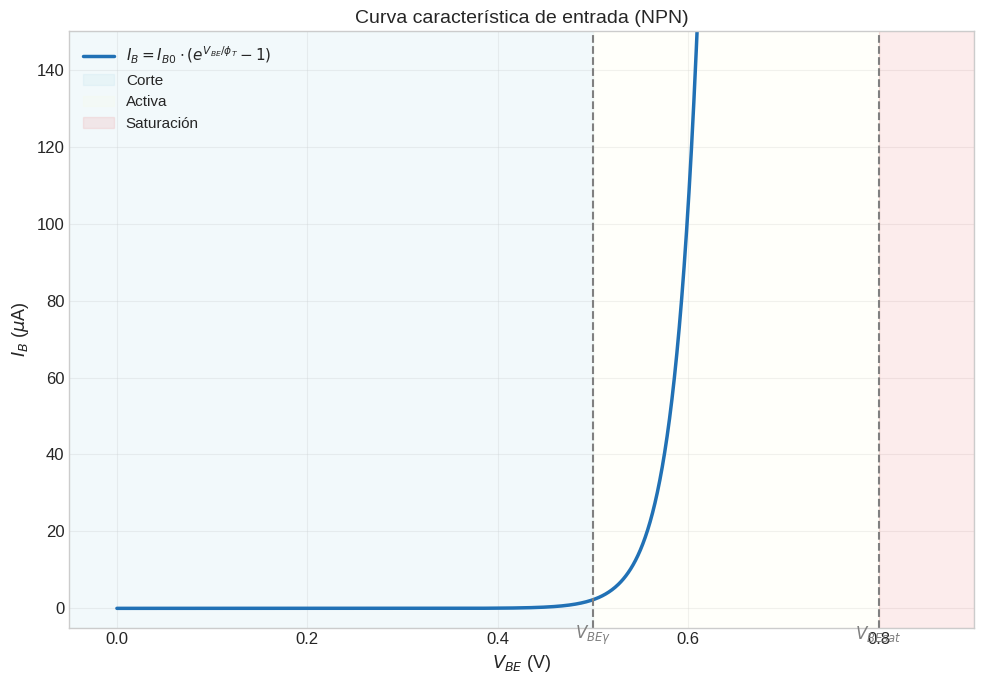

In [4]:
# Curva característica de ENTRADA
fig, ax = plt.subplots(figsize=(10, 7))
phi_T = 0.026; I_B0 = 1e-14; V_BE_gamma = 0.5; V_BE_sat = 0.8
V_BE = np.linspace(0, 0.85, 1000)
I_B = I_B0 * (np.exp(V_BE / phi_T) - 1)
I_B_uA = I_B * 1e6
mask = I_B_uA < 150
ax.plot(V_BE[mask], I_B_uA[mask], color=COLOR_PRINCIPAL, linewidth=2.5,
        label=r'$I_B = I_{B0} \cdot (e^{V_{BE}/\phi_T} - 1)$')
ax.axvspan(-0.1, V_BE_gamma, alpha=0.15, color='lightblue', label=r'Corte')
ax.axvspan(V_BE_gamma, V_BE_sat, alpha=0.15, color='lightyellow', label='Activa')
ax.axvspan(V_BE_sat, 0.9, alpha=0.15, color='lightcoral', label=r'Saturación')
ax.axvline(x=V_BE_gamma, color='gray', linestyle='--')
ax.axvline(x=V_BE_sat, color='gray', linestyle='--')
ax.text(V_BE_gamma, -8, r'$V_{BE\gamma}$', ha='center', fontsize=12, color='gray')
ax.text(V_BE_sat, -8, r'$V_{BEsat}$', ha='center', fontsize=12, color='gray')
ax.set_xlabel(r'$V_{BE}$ (V)'); ax.set_ylabel(r'$I_B$ ($\mu$A)')
ax.set_title('Curva característica de entrada (NPN)')
ax.set_xlim(-0.05, 0.9); ax.set_ylim(-5, 150)
ax.legend(fontsize=11, loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

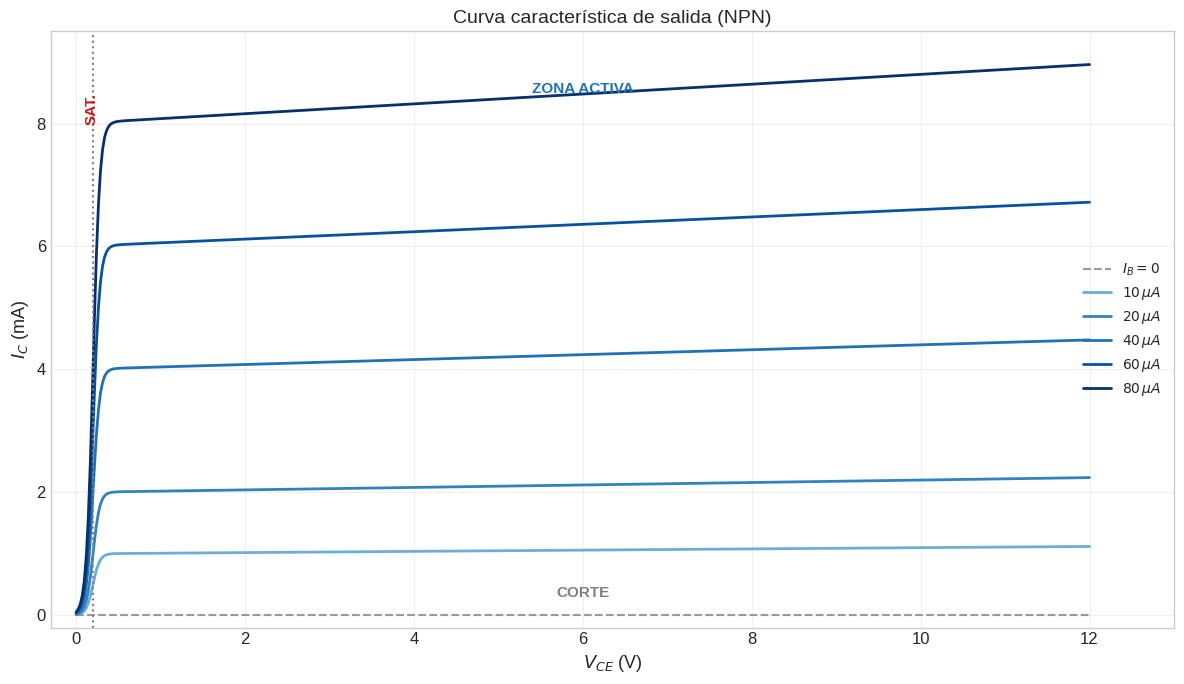

In [5]:
# Curva característica de SALIDA: familia de curvas
fig, ax = plt.subplots(figsize=(12, 7))
beta = 100; V_A = 100; V_CE_sat = 0.2
V_CE = np.linspace(0, 12, 500)
for ib, color, etiq in zip([0, 10e-6, 20e-6, 40e-6, 60e-6, 80e-6],
                            ['#999999','#6baed6','#3182bd','#2171b5','#08519c','#08306b'],
                            [r'$I_B=0$',r'$10\,\mu A$',r'$20\,\mu A$',
                             r'$40\,\mu A$',r'$60\,\mu A$',r'$80\,\mu A$']):
    if ib == 0:
        ax.plot(V_CE, np.full_like(V_CE, 0.01), color=color, lw=1.5, ls='--', label=etiq)
    else:
        ic = beta * ib * (1 + V_CE/V_A) * np.clip((np.tanh((V_CE-V_CE_sat)/0.08)+1)/2, 0, 1)
        ax.plot(V_CE, ic*1e3, color=color, lw=2, label=etiq)
ax.axvline(x=V_CE_sat, color='gray', ls=':', lw=1.5)
ax.text(0.1, 8.5, 'SAT.', fontsize=11, color=COLOR_RECTA, fontweight='bold', rotation=90, va='top')
ax.text(6, 8.5, 'ZONA ACTIVA', fontsize=11, color=COLOR_PRINCIPAL, fontweight='bold', ha='center')
ax.text(6, 0.3, 'CORTE', fontsize=11, color='gray', fontweight='bold', ha='center')
ax.set_xlabel(r'$V_{CE}$ (V)'); ax.set_ylabel(r'$I_C$ (mA)')
ax.set_title('Curva característica de salida (NPN)')
ax.set_xlim(-0.3, 13); ax.set_ylim(-0.2, 9.5)
ax.legend(fontsize=10, loc='center right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

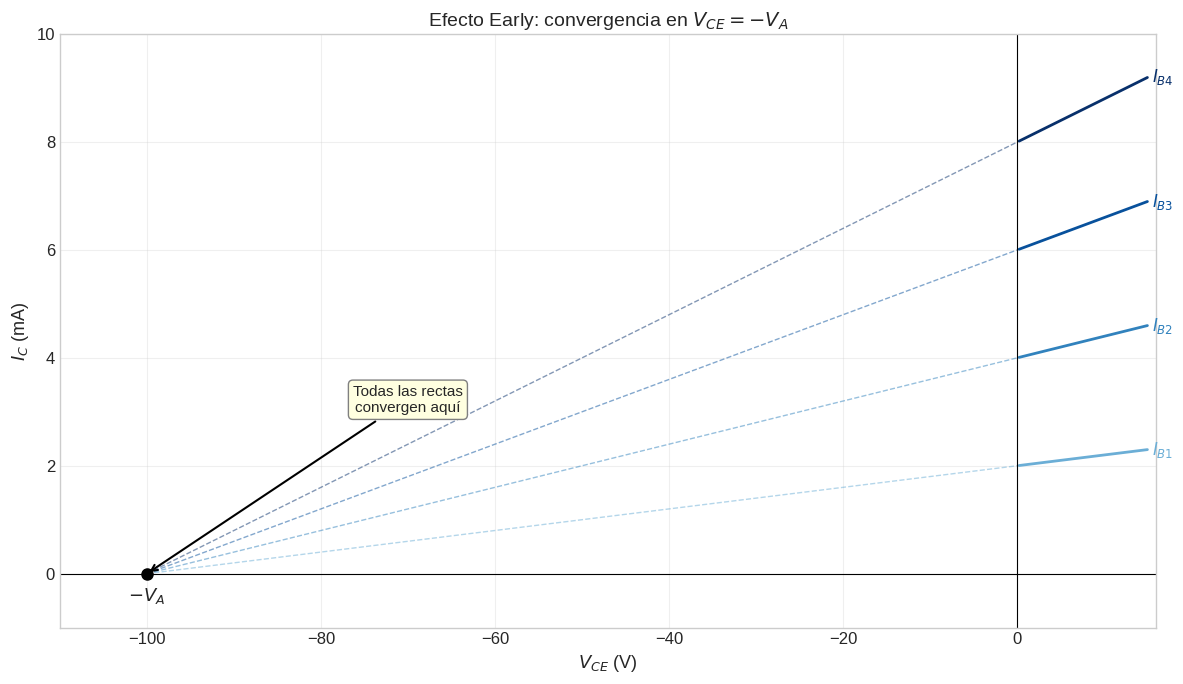

In [6]:
# Efecto Early
fig, ax = plt.subplots(figsize=(12, 7))
V_A = 100; beta = 100
V_CE_r = np.linspace(-V_A, 15, 500)
for ib, color, etiq in zip([20e-6,40e-6,60e-6,80e-6],
                            ['#6baed6','#3182bd','#08519c','#08306b'],
                            [r'$I_{B1}$',r'$I_{B2}$',r'$I_{B3}$',r'$I_{B4}$']):
    ic = beta * ib * (1 + V_CE_r / V_A)
    ax.plot(V_CE_r[V_CE_r>=0.2], ic[V_CE_r>=0.2]*1e3, color=color, lw=2)
    ax.plot(V_CE_r[V_CE_r<0.2], ic[V_CE_r<0.2]*1e3, color=color, lw=1, ls='--', alpha=0.5)
    ax.text(15.5, ic[-1]*1e3, etiq, fontsize=12, color=color, va='center')
ax.plot(-V_A, 0, 'ko', markersize=8)
ax.text(-V_A, -0.5, r'$-V_A$', fontsize=13, ha='center', fontweight='bold')
ax.annotate('Todas las rectas\nconvergen aquí', xy=(-V_A, 0), xytext=(-70, 3),
            fontsize=11, ha='center', arrowprops=dict(arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.axhline(y=0, color='black', lw=0.8); ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlabel(r'$V_{CE}$ (V)'); ax.set_ylabel(r'$I_C$ (mA)')
ax.set_title(r'Efecto Early: convergencia en $V_{CE} = -V_A$')
ax.set_xlim(-110, 16); ax.set_ylim(-1, 10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 4. Modelos de gran señal linealizados

Para resolver circuitos a mano, se sustituye el transistor por un **modelo simplificado** según su zona.

### 4.1 Transistor NPN

#### Corte
| Entrada | Salida | Modelo |
|:---:|:---:|:---:|
| $I_B = 0$ | $I_C = 0$ | Todo abierto |
| $V_{BE} < V_{BE\gamma}$ | | |

#### Activa
| Entrada | Salida | Modelo |
|:---:|:---:|:---:|
| $I_B > 0$ | $I_C = \beta \cdot I_B$ | B-E: fuente 0.7 V |
| $V_{BE} = V_{BE_{act}} \approx 0.7$ V | $V_{CE} > V_{CE_{sat}}$ | C-E: fuente de corriente $\beta I_B$ |

#### Saturación
| Entrada | Salida | Modelo |
|:---:|:---:|:---:|
| $I_B > 0$ | $I_C < \beta \cdot I_B$ | B-E: fuente 0.8 V |
| $V_{BE} = V_{BE_{sat}} \approx 0.8$ V | $V_{CE} = V_{CE_{sat}} \approx 0.2$ V | C-E: fuente 0.2 V |

### 4.2 Transistor PNP

Mismas ecuaciones pero con $V_{EB}$ y $V_{EC}$:
- **Corte**: $I_B = 0$, $V_{EB} < V_{EB\gamma}$
- **Activa**: $V_{EB} = 0.7$ V, $I_C = \beta \cdot I_B$, $V_{EC} > V_{EC_{sat}}$
- **Saturación**: $V_{EB} = 0.8$ V, $V_{EC} = 0.2$ V, $I_C < \beta \cdot I_B$

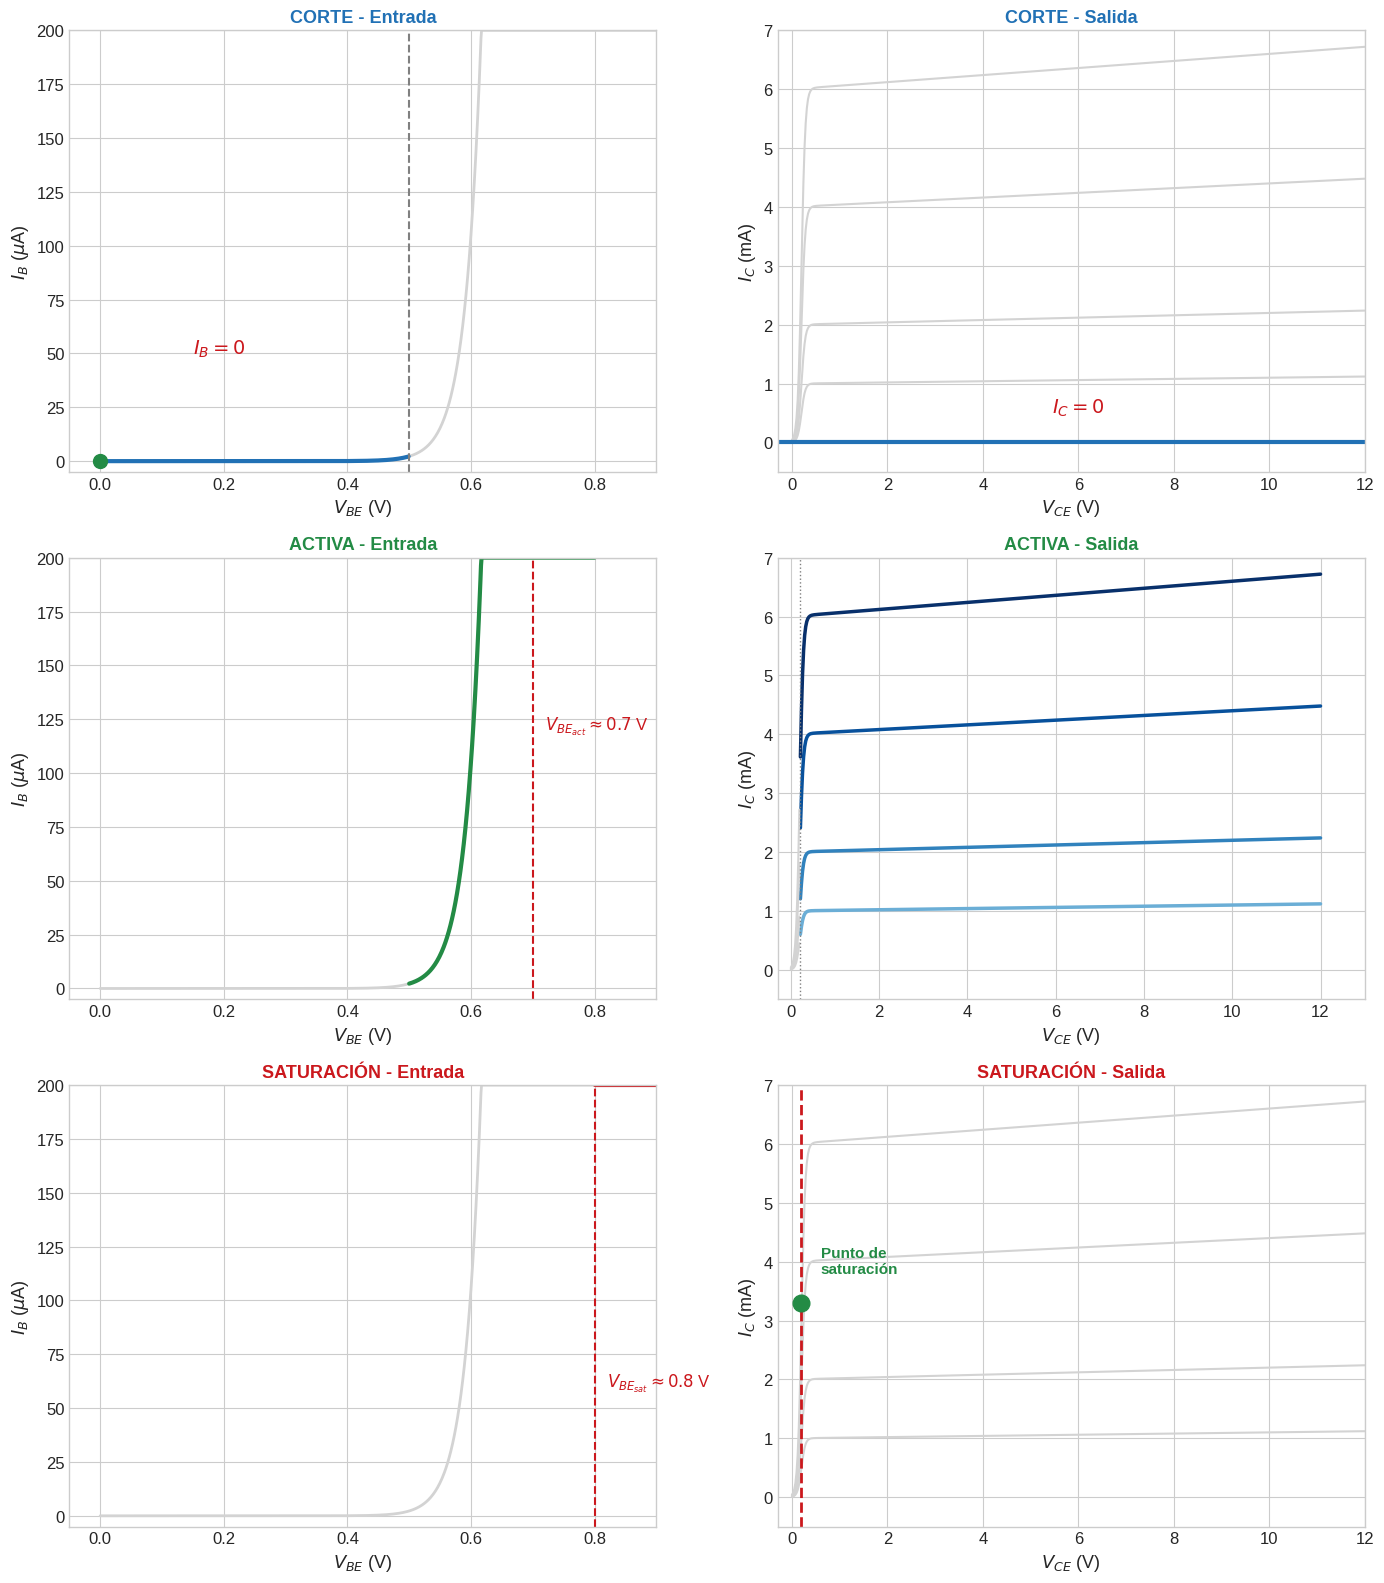

In [7]:
# Modelos linealizados: visualización de las 3 zonas
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
phi_T = 0.026; I_B0 = 1e-14; beta = 100
V_BE_range = np.linspace(0, 0.9, 1000)
I_B_curva = np.clip(I_B0 * (np.exp(V_BE_range / phi_T) - 1) * 1e6, 0, 200)
V_CE_range = np.linspace(0, 12, 500)
I_B_vals_out = [10e-6, 20e-6, 40e-6, 60e-6]
colores_act = ['#6baed6', '#3182bd', '#08519c', '#08306b']

def curva_salida(ib):
    ic = beta * ib * (1 + V_CE_range / 100)
    f = np.clip((np.tanh((V_CE_range - 0.2) / 0.08) + 1) / 2, 0, 1)
    return ic * f * 1e3

# CORTE
axes[0,0].set_title('CORTE - Entrada', fontsize=13, fontweight='bold', color=COLOR_PRINCIPAL)
axes[0,0].plot(V_BE_range, I_B_curva, color='lightgray', lw=2)
axes[0,0].plot(V_BE_range[V_BE_range<0.5], I_B_curva[V_BE_range<0.5], color=COLOR_PRINCIPAL, lw=3)
axes[0,0].axvline(x=0.5, color='gray', ls='--')
axes[0,0].plot(0, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
axes[0,0].text(0.15, 50, r'$I_B = 0$', fontsize=14, color=COLOR_RECTA, fontweight='bold')
axes[0,0].set_xlabel(r'$V_{BE}$ (V)'); axes[0,0].set_ylabel(r'$I_B$ ($\mu$A)')
axes[0,0].set_xlim(-0.05, 0.9); axes[0,0].set_ylim(-5, 200)

axes[0,1].set_title('CORTE - Salida', fontsize=13, fontweight='bold', color=COLOR_PRINCIPAL)
for ib in I_B_vals_out:
    axes[0,1].plot(V_CE_range, curva_salida(ib), color='lightgray', lw=1.5)
axes[0,1].axhline(y=0, color=COLOR_PRINCIPAL, lw=3)
axes[0,1].text(6, 0.5, r'$I_C = 0$', fontsize=14, color=COLOR_RECTA, fontweight='bold', ha='center')
axes[0,1].set_xlabel(r'$V_{CE}$ (V)'); axes[0,1].set_ylabel(r'$I_C$ (mA)')
axes[0,1].set_xlim(-0.3, 12); axes[0,1].set_ylim(-0.5, 7)

# ACTIVA
axes[1,0].set_title('ACTIVA - Entrada', fontsize=13, fontweight='bold', color=COLOR_PUNTO)
axes[1,0].plot(V_BE_range, I_B_curva, color='lightgray', lw=2)
m = (V_BE_range >= 0.5) & (V_BE_range <= 0.8)
axes[1,0].plot(V_BE_range[m], I_B_curva[m], color=COLOR_PUNTO, lw=3)
axes[1,0].axvline(x=0.7, color=COLOR_RECTA, ls='--', lw=1.5)
axes[1,0].text(0.72, 120, r'$V_{BE_{act}} \approx 0.7$ V', fontsize=12, color=COLOR_RECTA)
axes[1,0].set_xlabel(r'$V_{BE}$ (V)'); axes[1,0].set_ylabel(r'$I_B$ ($\mu$A)')
axes[1,0].set_xlim(-0.05, 0.9); axes[1,0].set_ylim(-5, 200)

axes[1,1].set_title('ACTIVA - Salida', fontsize=13, fontweight='bold', color=COLOR_PUNTO)
for ib, color in zip(I_B_vals_out, colores_act):
    cs = curva_salida(ib)
    axes[1,1].plot(V_CE_range[V_CE_range>0.2], cs[V_CE_range>0.2], color=color, lw=2.5)
    axes[1,1].plot(V_CE_range[V_CE_range<=0.2], cs[V_CE_range<=0.2], color='lightgray', lw=1.5)
axes[1,1].axvline(x=0.2, color='gray', ls=':', lw=1)
axes[1,1].set_xlabel(r'$V_{CE}$ (V)'); axes[1,1].set_ylabel(r'$I_C$ (mA)')
axes[1,1].set_xlim(-0.3, 13); axes[1,1].set_ylim(-0.5, 7)

# SATURACIÓN
axes[2,0].set_title('SATURACIÓN - Entrada', fontsize=13, fontweight='bold', color=COLOR_RECTA)
axes[2,0].plot(V_BE_range, I_B_curva, color='lightgray', lw=2)
axes[2,0].plot(V_BE_range[V_BE_range>=0.8], np.clip(I_B_curva[V_BE_range>=0.8],0,200),
               color=COLOR_RECTA, lw=3)
axes[2,0].axvline(x=0.8, color=COLOR_RECTA, ls='--', lw=1.5)
axes[2,0].text(0.82, 60, r'$V_{BE_{sat}} \approx 0.8$ V', fontsize=12, color=COLOR_RECTA)
axes[2,0].set_xlabel(r'$V_{BE}$ (V)'); axes[2,0].set_ylabel(r'$I_B$ ($\mu$A)')
axes[2,0].set_xlim(-0.05, 0.9); axes[2,0].set_ylim(-5, 200)

axes[2,1].set_title('SATURACIÓN - Salida', fontsize=13, fontweight='bold', color=COLOR_RECTA)
for ib, color in zip(I_B_vals_out, colores_act):
    axes[2,1].plot(V_CE_range, curva_salida(ib), color='lightgray', lw=1.5)
axes[2,1].axvline(x=0.2, color=COLOR_RECTA, ls='--', lw=2)
axes[2,1].plot(0.2, 3.3, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
axes[2,1].text(0.6, 3.8, 'Punto de\nsaturación', fontsize=11, color=COLOR_PUNTO, fontweight='bold')
axes[2,1].set_xlabel(r'$V_{CE}$ (V)'); axes[2,1].set_ylabel(r'$I_C$ (mA)')
axes[2,1].set_xlim(-0.3, 12); axes[2,1].set_ylim(-0.5, 7)

plt.tight_layout(); plt.show()

---
## 5. Metodología de resolución de ejercicios

### Paso 0: Truco rápido para predecir el estado (30 segundos)

Antes de resolver, puedes saber el estado del transistor con este método universal de **3 pasos**:

**1.** Calcular $I_B$ suponiendo activa (usando la fórmula del tipo de circuito correspondiente)

**2.** Calcular la corriente máxima que permite el circuito:

$$I_{C_{max}} = \frac{V_{CC}}{R_C + R_E}$$

**3.** Comparar $\beta \cdot I_B$ con $I_{C_{max}}$:

$$\beta \cdot I_B < I_{C_{max}} \to \textbf{ACTIVA} \qquad \beta \cdot I_B > I_{C_{max}} \to \textbf{SATURACIÓN}$$

**Esto funciona para TODOS los tipos de circuitos** porque no depende de dónde está conectada $R_B$. La fórmula de $I_B$ ya incluye la topología.

#### Atajo aún más rápido (solo para polarización fija)

En polarización fija ($R_B$ conectada a $V_{CC}$), los $V_{CC}$ se cancelan y queda:

$$\frac{R_B}{R_C} < \beta \to \text{Saturación} \qquad \frac{R_B}{R_C} > \beta \to \text{Activa}$$

**Ojo**: este atajo **NO funciona** para retroalimentación de colector (Tipo 4), porque $R_B$ no está conectada a un punto de tensión fija. En ese caso, usar siempre el método universal.

---

### Los 5 pasos de resolución

### Paso 1: Fijar referencias
Establecer $V_{BE}$, $V_{CE}$ (NPN) o $V_{EB}$, $V_{EC}$ (PNP) y las corrientes $I_B$, $I_C$, $I_E$.

### Paso 2: Suponer un estado
Usar el **Paso 0** para elegir el estado inicial (activa o saturación). Si no estás seguro, empezar suponiendo **Activa**.

### Paso 3: Sustituir por el modelo
- **Activa**: B-E = fuente de 0.7 V, C-E = fuente de corriente $\beta \cdot I_B$
- **Saturación**: B-E = fuente de 0.8 V, C-E = fuente de 0.2 V
- **Corte**: todo abierto

### Paso 4: Resolver las ecuaciones
Aplicar KVL a las mallas del circuito.

### Paso 5: Verificar la hipótesis
- **Activa**: comprobar $V_{CE} > V_{CE_{sat}}$ y $I_B > 0$
- **Saturación**: comprobar $I_C < \beta \cdot I_B$
- **Corte**: comprobar $V_{BE} < V_{BE\gamma}$

Si falla, volver al Paso 2 con otro estado.

---
## 6. Ejemplo resuelto: Transistor NPN (2N2222)

### Datos del circuito

$V_1 = 5$ V, $V_{CC} = 10$ V, $R_B = 100$ k$\Omega$, $R_C = 1.1$ k$\Omega$, $\beta = 100$

### Resolución paso a paso

**Paso 1-2:** Suponemos zona **Activa** ($V_{BE} = 0.7$ V)

**Paso 3-4:** Malla de base (KVL):

$$-V_1 + R_B \cdot I_B + V_{BE} = 0 \implies I_B = \frac{V_1 - V_{BE}}{R_B} = \frac{5 - 0.7}{100\text{k}\Omega} = 43\;\mu\text{A}$$

Corriente de colector:

$$I_C = \beta \cdot I_B = 100 \times 43\;\mu\text{A} = 4.30\;\text{mA}$$

Malla de colector (KVL):

$$V_{CE} = V_{CC} - R_C \cdot I_C = 10 - 1.1\text{k}\Omega \times 4.30\;\text{mA} = 5.27\;\text{V}$$

**Paso 5:** Verificar: $V_{CE} = 5.27$ V $> V_{CE_{sat}} = 0.2$ V. **ACTIVA confirmada.**

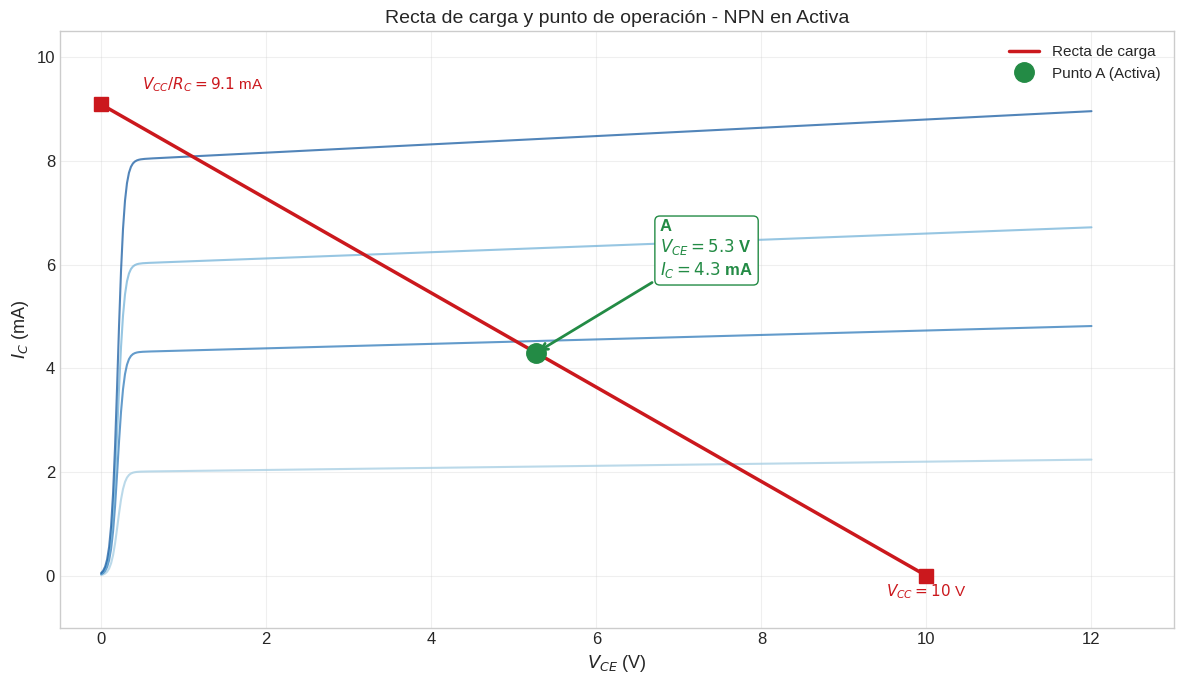

In [8]:
# Recta de carga con punto de operación - NPN Activa
V1 = 5; Vcc = 10; R_B = 100e3; R_C = 1.1e3; beta_npn = 100
V_BE_act = 0.7; V_CE_sat = 0.2

I_B = (V1 - V_BE_act) / R_B
I_C = beta_npn * I_B
V_CE = Vcc - R_C * I_C

fig, ax = plt.subplots(figsize=(12, 7))
V_CE_recta = np.linspace(0, Vcc, 100)
I_C_recta = (Vcc - V_CE_recta) / R_C

# Curvas de salida
V_CE_curva = np.linspace(0, 12, 500)
for ib, color in zip([20e-6, 43e-6, 60e-6, 80e-6],
                     ['#9ecae1', '#2171b5', '#6baed6', '#08519c']):
    ic = beta_npn*ib*(1+V_CE_curva/100)*np.clip((np.tanh((V_CE_curva-0.2)/0.08)+1)/2,0,1)
    ax.plot(V_CE_curva, ic*1e3, color=color, lw=1.5, alpha=0.7)

ax.plot(V_CE_recta, I_C_recta*1e3, color=COLOR_RECTA, lw=2.5, label='Recta de carga')
ax.plot(V_CE, I_C*1e3, 'o', color=COLOR_PUNTO, ms=14, zorder=5, label='Punto A (Activa)')
ax.annotate(f'A\n$V_{{CE}}={V_CE:.1f}$ V\n$I_C={I_C*1e3:.1f}$ mA',
            xy=(V_CE, I_C*1e3), xytext=(V_CE+1.5, I_C*1e3+1.5),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))
ax.plot(Vcc, 0, 's', color=COLOR_RECTA, ms=10)
ax.text(Vcc, -0.4, f'$V_{{CC}}={Vcc}$ V', ha='center', fontsize=11, color=COLOR_RECTA)
ax.plot(0, Vcc/R_C*1e3, 's', color=COLOR_RECTA, ms=10)
ax.text(0.5, Vcc/R_C*1e3+0.3, f'$V_{{CC}}/R_C={Vcc/R_C*1e3:.1f}$ mA', fontsize=11, color=COLOR_RECTA)
ax.set_xlabel(r'$V_{CE}$ (V)'); ax.set_ylabel(r'$I_C$ (mA)')
ax.set_title('Recta de carga y punto de operación - NPN en Activa')
ax.set_xlim(-0.5, 13); ax.set_ylim(-1, 10.5)
ax.legend(fontsize=11, loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 6.1 Variación: $R_C = 3$ k$\Omega$ (entra en saturación)

Al aumentar $R_C$, la pendiente de la recta de carga disminuye y el punto de operación se desplaza hacia la zona de saturación. Veamos qué ocurre:

**Intento 1: suponer Activa**

$$I_B = \frac{5 - 0.7}{100\text{k}\Omega} = 43\;\mu\text{A} \qquad I_C = 100 \times 43\;\mu\text{A} = 4.3\;\text{mA}$$

$$V_{CE} = 10 - 3\text{k}\Omega \times 4.3\;\text{mA} = 10 - 12.9 = -2.9\;\text{V}$$

$V_{CE}$ es **negativo**, lo cual es imposible. La hipótesis de activa **falla**.

**Intento 2: suponer Saturación** ($V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V)

$$I_B = \frac{5 - 0.8}{100\text{k}\Omega} = 42\;\mu\text{A}$$

$$I_C = \frac{V_{CC} - V_{CE_{sat}}}{R_C} = \frac{10 - 0.2}{3\text{k}\Omega} = 3.27\;\text{mA}$$

**Verificar**: $I_C = 3.27$ mA $< \beta \cdot I_B = 100 \times 42\;\mu\text{A} = 4.2$ mA. **SATURACIÓN confirmada.**

**Conclusión**: al aumentar $R_C$, la caída de tensión en ella es tan grande que "absorbe" toda la tensión $V_{CC}$ y el transistor no puede mantener $V_{CE} > V_{CE_{sat}}$. El punto de operación cae en la zona de saturación.

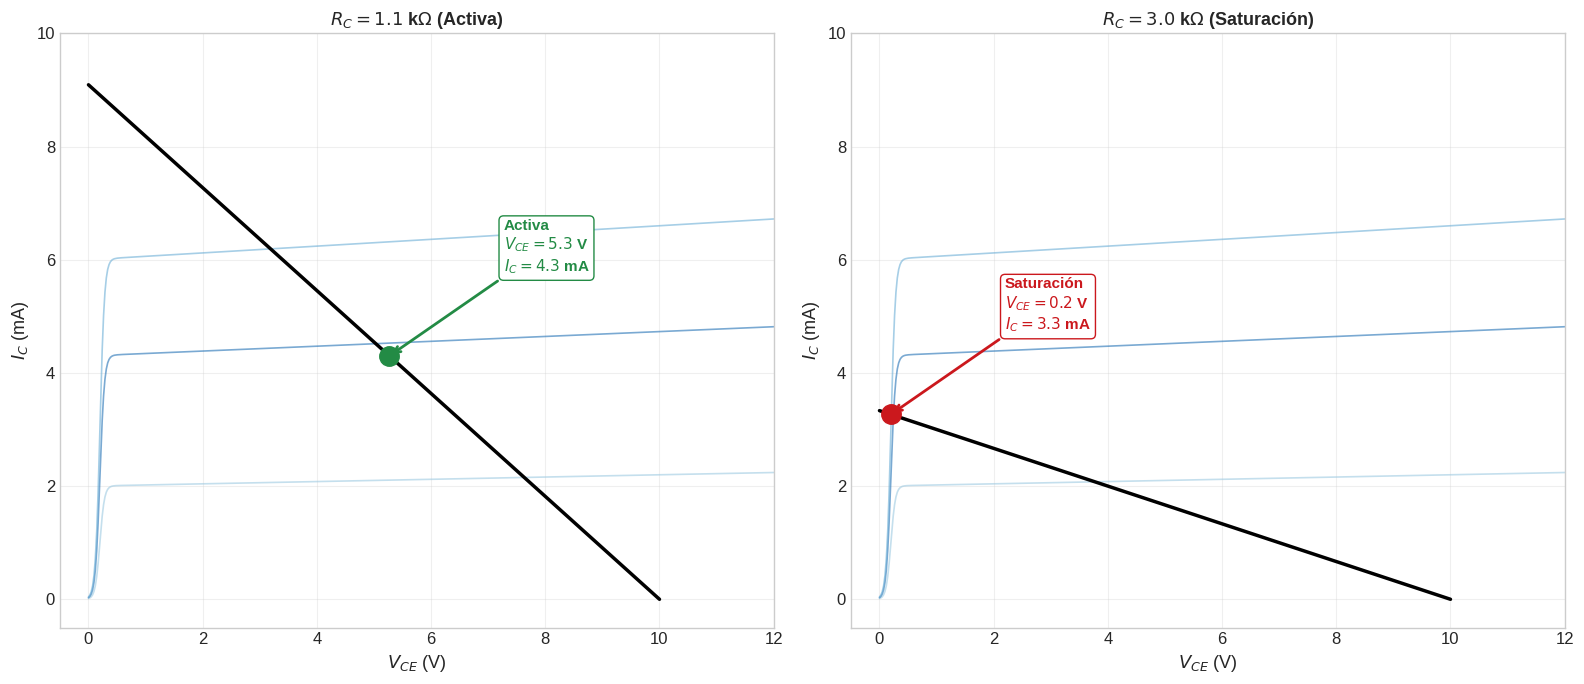

In [9]:
# Comparativa Activa vs Saturación
R_C_sat = 3e3
I_B_sat = (V1 - 0.8) / R_B
I_C_sat = (Vcc - 0.2) / R_C_sat

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for idx, (rc, vce_op, ic_op, estado, col) in enumerate([
    (1.1e3, V_CE, I_C, 'Activa', COLOR_PUNTO),
    (3e3, 0.2, I_C_sat, 'Saturación', COLOR_RECTA)]):
    ax = axes[idx]
    V_CE_curva = np.linspace(0, 12, 500)
    for ib, c in zip([20e-6, 43e-6, 60e-6], ['#9ecae1','#2171b5','#6baed6']):
        ic = beta_npn*ib*(1+V_CE_curva/100)*np.clip((np.tanh((V_CE_curva-0.2)/0.08)+1)/2,0,1)
        ax.plot(V_CE_curva, ic*1e3, color=c, lw=1.2, alpha=0.6)
    vr = np.linspace(0, Vcc, 100)
    ax.plot(vr, (Vcc-vr)/rc*1e3, color='black', lw=2.5)
    ax.plot(vce_op, ic_op*1e3, 'o', color=col, ms=14, zorder=5)
    ax.annotate(f'{estado}\n$V_{{CE}}={vce_op:.1f}$ V\n$I_C={ic_op*1e3:.1f}$ mA',
                xy=(vce_op, ic_op*1e3), xytext=(vce_op+2, ic_op*1e3+1.5),
                fontsize=11, color=col, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=col, lw=2),
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=col))
    ax.set_xlabel(r'$V_{CE}$ (V)'); ax.set_ylabel(r'$I_C$ (mA)')
    ax.set_title(f'$R_C = {rc/1e3:.1f}$ k$\\Omega$ ({estado})', fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, 12); ax.set_ylim(-0.5, 10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 7. Ejemplo resuelto: Transistor PNP

### Datos del circuito

$V_{CC} = 10$ V (al emisor), $V_1 = 5$ V (base), $R_B = 100$ k$\Omega$, $R_C = 1.1$ k$\Omega$, $\beta = 100$

### Resolución paso a paso

**Paso 1:** En un PNP, las referencias son $V_{EB}$ y $V_{EC}$. La corriente principal entra por el emisor.

**Paso 2:** Suponemos **Activa** ($V_{EB} = 0.7$ V)

**Paso 3-4:** Malla de base:

$$I_B = \frac{V_{CC} - V_{EB} - V_1}{R_B} = \frac{10 - 0.7 - 5}{100\text{k}\Omega} = 43\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 43\;\mu\text{A} = 4.30\;\text{mA}$$

$$V_{EC} = V_{CC} - R_C \cdot I_C = 10 - 1.1\text{k}\Omega \times 4.30\;\text{mA} = 5.27\;\text{V}$$

**Paso 5:** $V_{EC} = 5.27$ V $> 0.2$ V. **ACTIVA confirmada.**

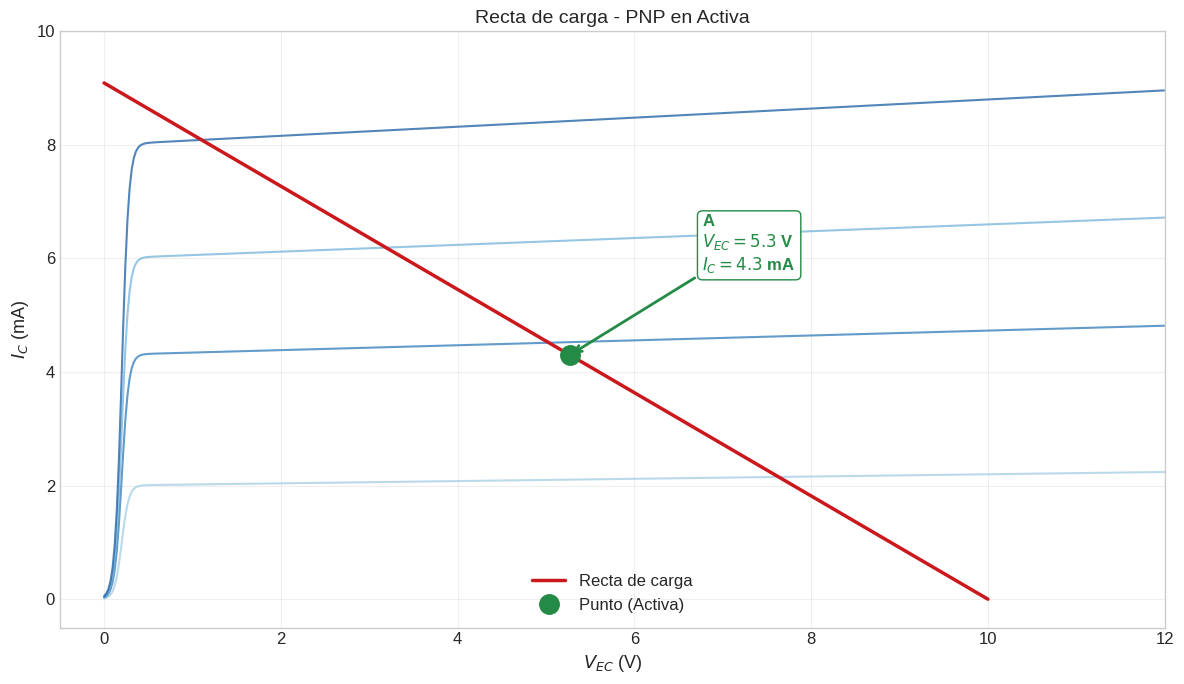

In [10]:
# Recta de carga PNP
I_B_pnp = (10 - 0.7 - 5) / 100e3
I_C_pnp = 100 * I_B_pnp
V_EC_pnp = 10 - 1.1e3 * I_C_pnp

fig, ax = plt.subplots(figsize=(12, 7))
V_EC_curva = np.linspace(0, 12, 500)
for ib, color in zip([20e-6, 43e-6, 60e-6, 80e-6],
                     ['#9ecae1', '#2171b5', '#6baed6', '#08519c']):
    ic = 100*ib*(1+V_EC_curva/100)*np.clip((np.tanh((V_EC_curva-0.2)/0.08)+1)/2,0,1)
    ax.plot(V_EC_curva, ic*1e3, color=color, lw=1.5, alpha=0.7)

V_EC_recta = np.linspace(0, 10, 100)
ax.plot(V_EC_recta, (10-V_EC_recta)/1.1e3*1e3, color=COLOR_RECTA, lw=2.5, label='Recta de carga')
ax.plot(V_EC_pnp, I_C_pnp*1e3, 'o', color=COLOR_PUNTO, ms=14, zorder=5, label='Punto (Activa)')
ax.annotate(f'A\n$V_{{EC}}={V_EC_pnp:.1f}$ V\n$I_C={I_C_pnp*1e3:.1f}$ mA',
            xy=(V_EC_pnp, I_C_pnp*1e3), xytext=(V_EC_pnp+1.5, I_C_pnp*1e3+1.5),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))
ax.set_xlabel(r'$V_{EC}$ (V)'); ax.set_ylabel(r'$I_C$ (mA)')
ax.set_title('Recta de carga - PNP en Activa')
ax.set_xlim(-0.5, 12); ax.set_ylim(-0.5, 10)
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 8. Estabilización con resistencia de emisor ($R_E$)

El parámetro $\beta$ varía mucho entre transistores y con la temperatura. La resistencia $R_E$ crea **realimentación negativa** que estabiliza $I_C$:

1. Si $I_C$ sube $\to$ $I_E$ sube $\to$ $V_{R_E}$ sube $\to$ $V_{BE}$ efectiva baja $\to$ $I_B$ baja $\to$ $I_C$ se corrige

$$I_B = \frac{V_1 - V_{BE}}{R_B + R_E(\beta+1)} \qquad I_C = \beta \cdot I_B$$

Para $\beta$ muy grande: $I_C \approx \dfrac{V_1 - V_{BE}}{R_E}$ (independiente de $\beta$).

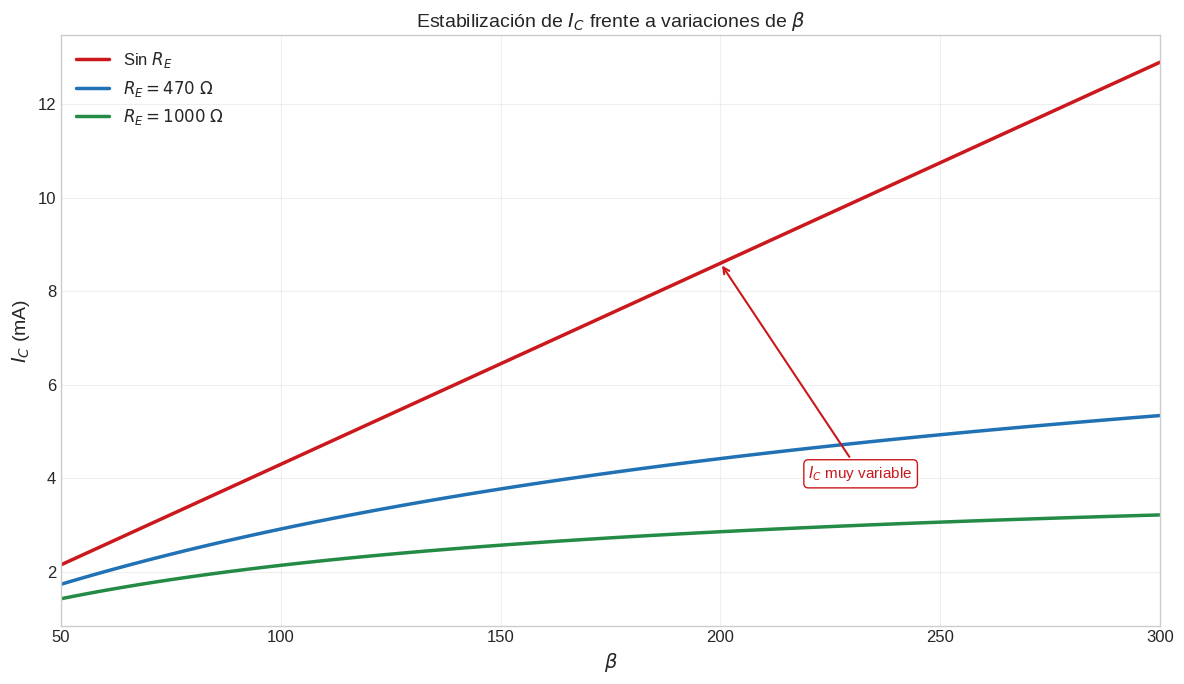

In [11]:
# Demostración de estabilización con RE
V1_re = 5; V_BE_re = 0.7; R_B_re = 100e3; R_E_vals = [0, 470, 1000]
betas = np.linspace(50, 300, 100)

fig, ax = plt.subplots(figsize=(12, 7))
colores_re = [COLOR_RECTA, COLOR_PRINCIPAL, COLOR_PUNTO]
for R_E, color in zip(R_E_vals, colores_re):
    if R_E == 0:
        I_B = (V1_re - V_BE_re) / R_B_re
        I_C = betas * I_B
        lbl = r'Sin $R_E$'
    else:
        I_B = (V1_re - V_BE_re) / (R_B_re + R_E * (betas + 1))
        I_C = betas * I_B
        lbl = f'$R_E = {R_E}$ ' + r'$\Omega$'
    ax.plot(betas, I_C*1e3, color=color, lw=2.5, label=lbl)

ax.set_xlabel(r'$\beta$', fontsize=14); ax.set_ylabel(r'$I_C$ (mA)', fontsize=14)
ax.set_title(r'Estabilización de $I_C$ frente a variaciones de $\beta$')
ax.legend(fontsize=12, loc='upper left'); ax.grid(True, alpha=0.3); ax.set_xlim(50, 300)
ax.annotate(r'$I_C$ muy variable', xy=(200, 200*(V1_re-V_BE_re)/R_B_re*1e3),
            xytext=(220, 4), fontsize=11, color=COLOR_RECTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))
plt.tight_layout(); plt.show()

---
## 9. Resumen visual: NPN vs PNP

| Concepto | NPN | PNP |
|----------|-----|-----|
| Estructura | N - P - N | P - N - P |
| Flecha emisor | Sale | Entra |
| Tensiones | $V_{BE}$, $V_{CE}$ | $V_{EB}$, $V_{EC}$ |
| Corrientes | Entran por B y C | Salen por B y C |
| Activa: entrada | $V_{BE} = 0.7$ V | $V_{EB} = 0.7$ V |
| Activa: salida | $I_C = \beta \cdot I_B$ | $I_C = \beta \cdot I_B$ |
| Saturación | $V_{CE} = V_{CEsat}$ | $V_{EC} = V_{ECsat}$ |
| Corte | $I_B = 0$, $I_C = 0$ | $I_B = 0$, $I_C = 0$ |

---
## 10. Catálogo de circuitos de polarización: todos los tipos de ejercicios

Conocer los **patrones de circuitos** es la clave para resolver cualquier ejercicio. La metodología de 5 pasos siempre es la misma; lo que cambia es **cómo se plantean las ecuaciones de malla**.

| # | Tipo | Componentes | Estabilidad | Dificultad |
|---|------|-------------|-------------|------------|
| 1 | Polarización fija | $R_B + R_C$ | Muy baja | Baja |
| 2 | Dos fuentes | $R_B + R_C + V_{BB} + V_{CC}$ | Baja | Baja |
| 3 | Con $R_E$ | $R_B + R_C + R_E$ | Media | Media |
| 4 | Realimentación de colector | $R_B$ (de C a B) + $R_C$ | Media-alta | Media |
| 5 | Divisor de tensión | $R_1 + R_2 + R_C + R_E$ | Alta | Media |
| 6 | PNP (cualquier topología) | Varía | Varía | +1 nivel |
| 7 | Circuitos combinados | Múltiples elementos | Varía | Alta |

**Regla de oro:** En todos los casos, la fórmula de $I_B$ tiene la misma estructura:

$$I_B = \frac{\text{Tensión disponible} - V_{BE}}{\text{Resistencia vista desde la base}}$$

Lo que cambia entre tipos es **qué resistencia "ve" la base**.

### 10.1 Tipo 1: Polarización fija ($R_B + R_C$)

El circuito **más simple**. Una sola fuente $V_{CC}$ alimenta tanto la malla de base (a través de $R_B$) como la de colector ($R_C$).

$$\boxed{I_B = \frac{V_{CC} - V_{BE}}{R_B}} \qquad I_C = \beta \cdot I_B \qquad V_{CE} = V_{CC} - R_C \cdot I_C$$

**Cómo afectan las resistencias al punto de operación:**
- Si **$R_B$ aumenta** $\to$ $I_B$ disminuye $\to$ $I_C$ disminuye $\to$ $V_{CE}$ aumenta (se aleja de saturación)
- Si **$R_B$ disminuye** $\to$ $I_B$ aumenta $\to$ $I_C$ aumenta $\to$ $V_{CE}$ disminuye (se acerca a saturación)
- Si **$R_C$ aumenta** $\to$ la caída $R_C \cdot I_C$ aumenta $\to$ $V_{CE}$ disminuye (puede entrar en saturación)
- Si **$R_C$ disminuye** $\to$ $V_{CE}$ aumenta

**Problema**: $I_C$ depende directamente de $\beta$. Si $\beta$ varía (por temperatura o dispersión), el punto de operación se desplaza. **No se usa en la práctica.**

#### Ejercicio resuelto: Tipo 1

**Datos:** $V_{CC} = 12$ V, $R_B = 240$ k$\Omega$, $R_C = 2.2$ k$\Omega$, $\beta = 100$

**Paso 1-2:** Suponer Activa ($V_{BE} = 0.7$ V)

**Paso 3-4:**

$$I_B = \frac{V_{CC} - V_{BE}}{R_B} = \frac{12 - 0.7}{240\text{k}\Omega} = 47.08\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 47.08 = 4.71\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C = 12 - 2.2\text{k} \times 4.71 = 1.64\;\text{V}$$

**Paso 5:** $V_{CE} = 1.64$ V $> 0.2$ V $\to$ **ACTIVA confirmada.**

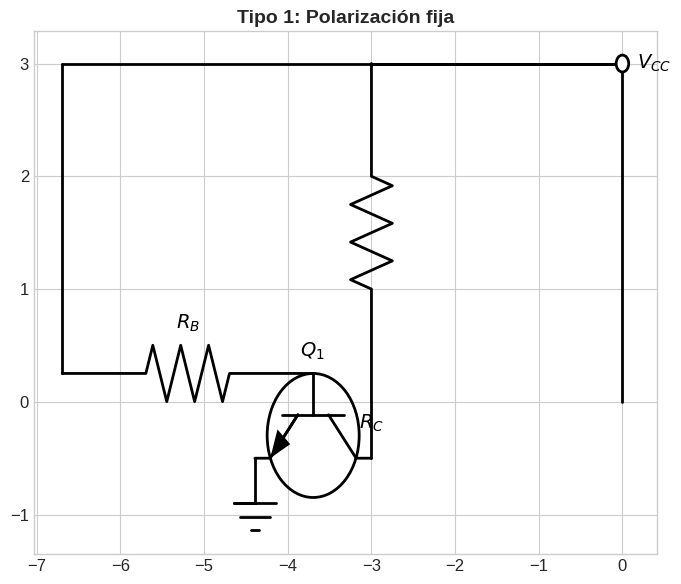

In [12]:
# Tipo 1: Diagrama del circuito
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Tipo 1: Polarización fija', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(3)
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
top = d.here
d += elm.Line().left().length(3)
d += elm.Resistor().down().label('$R_C$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Ground().at(bjt.emitter)
d += elm.Resistor().at(bjt.base).left().length(3).label('$R_B$', loc='top')
d += elm.Line().up().toy(top)
d += elm.Line().right().tox(top)
d.draw()
plt.tight_layout(); plt.show()

### 10.2 Tipo 2: Dos fuentes ($V_{BB}$ + $V_{CC}$)

Fuentes independientes para base y colector. Es el circuito de los ejemplos del tema.

$$\boxed{I_B = \frac{V_{BB} - V_{BE}}{R_B}} \qquad I_C = \beta \cdot I_B \qquad V_{CE} = V_{CC} - R_C \cdot I_C$$

**Cómo afectan los parámetros:**
- **$V_{BB}$ controla $I_B$** (y por tanto $I_C$): al aumentar $V_{BB}$, aumenta $I_B$ y el punto de operación se acerca a saturación.
- **$V_{CC}$ desplaza la recta de carga horizontalmente**: al aumentar $V_{CC}$, el corte con el eje X se desplaza a la derecha, alejando el punto de operación de la saturación.
- **$R_C$ cambia la pendiente** de la recta de carga: mayor $R_C$ = menor pendiente = más fácil entrar en saturación.

Las mallas son **independientes**: la corriente $I_B$ no depende de $V_{CC}$ ni de $R_C$.

#### Ejercicio resuelto: Tipo 2

**Datos:** $V_{BB} = 5$ V, $V_{CC} = 10$ V, $R_B = 100$ k$\Omega$, $R_C = 1.1$ k$\Omega$, $\beta = 100$

$$I_B = \frac{5 - 0.7}{100\text{k}} = 43\;\mu\text{A} \qquad I_C = 100 \times 43 = 4.30\;\text{mA} \qquad V_{CE} = 10 - 1.1\text{k} \times 4.30 = 5.27\;\text{V}$$

$V_{CE} = 5.27$ V $> 0.2$ V $\to$ **ACTIVA.**

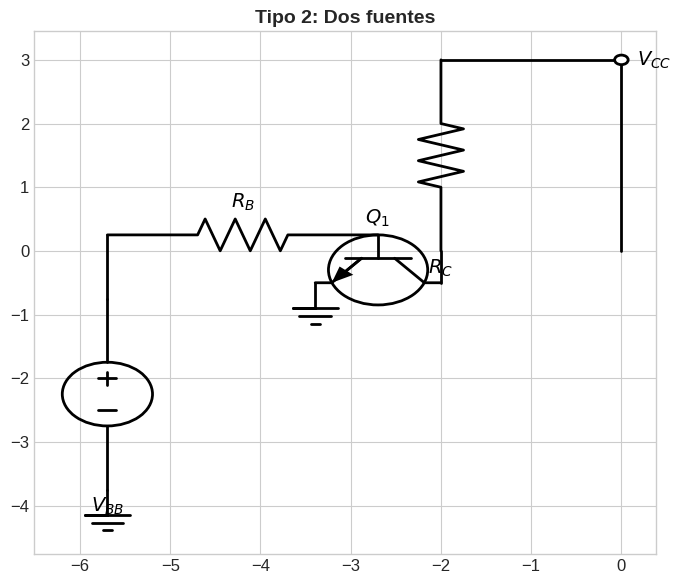

In [13]:
# Tipo 2: Diagrama
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Tipo 2: Dos fuentes', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(3)
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
top_r = d.here
d += elm.Line().left().length(2)
d += elm.Resistor().down().label('$R_C$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Ground().at(bjt.emitter)
d += elm.Resistor().at(bjt.base).left().length(3).label('$R_B$', loc='top')
d += elm.Line().down().length(1)
d += elm.SourceV().down().label('$V_{BB}$', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 10.3 Tipo 3: Con $R_E$ (estabilización por emisor)

Se añade $R_E$ en el emisor. La malla de base incluye ahora la caída en $R_E$:

$$V_{CC} = R_B \cdot I_B + V_{BE} + R_E \cdot I_E = R_B \cdot I_B + V_{BE} + R_E \cdot (\beta + 1) \cdot I_B$$

$$\boxed{I_B = \frac{V_{CC} - V_{BE}}{R_B + R_E \cdot (\beta + 1)}} \qquad V_{CE} = V_{CC} - R_C \cdot I_C - R_E \cdot I_E$$

**Cómo afecta $R_E$:**
- $R_E$ aparece **multiplicada por $(\beta+1)$** en el denominador. Esto significa que incluso una $R_E$ pequeña tiene un efecto enorme en $I_B$.
- Si $R_E$ es lo suficientemente grande, el denominador está dominado por $R_E \cdot (\beta+1)$ y los cambios en $\beta$ apenas afectan a $I_B$.
- **Compromiso**: una $R_E$ grande estabiliza pero también reduce $I_C$ y "desperdicia" tensión ($V_{R_E} = R_E \cdot I_E$), dejando menos margen para $V_{CE}$.

**Error frecuente en exámenes:** Olvidar que por $R_E$ circula $I_E = (\beta+1) \cdot I_B$, no $I_C$.

#### Ejercicio resuelto: Tipo 3

**Datos:** $V_{CC} = 12$ V, $R_B = 200$ k$\Omega$, $R_C = 1$ k$\Omega$, $R_E = 500\;\Omega$, $\beta = 100$

$$I_B = \frac{12 - 0.7}{200\text{k} + 500 \times 101} = \frac{11.3}{250\,500} = 45.11\;\mu\text{A}$$

$$I_C = 100 \times 45.11 = 4.51\;\text{mA} \qquad I_E = 101 \times 45.11 = 4.56\;\text{mA}$$

$$V_{CE} = 12 - 1\text{k} \times 4.51 - 500 \times 4.56 = 12 - 4.51 - 2.28 = 5.21\;\text{V}$$

$V_{CE} = 5.21$ V $> 0.2$ V $\to$ **ACTIVA.**

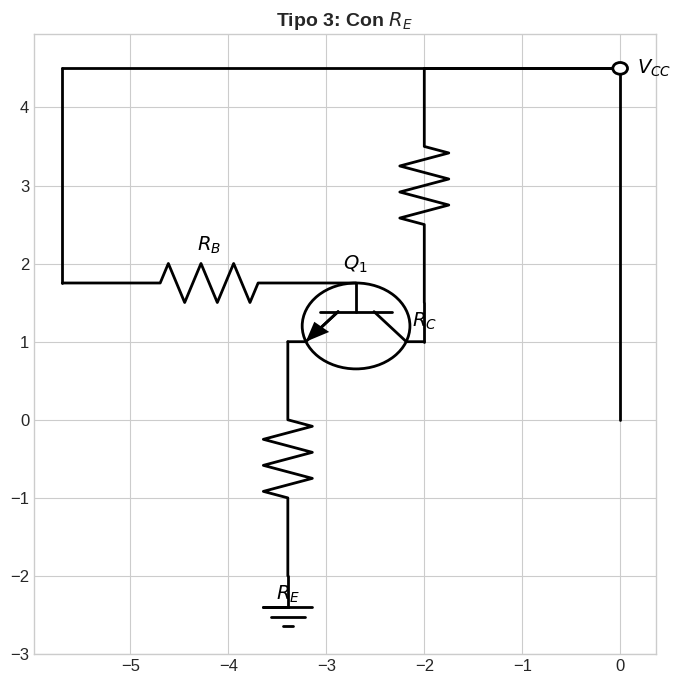

In [14]:
# Tipo 3: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 3: Con $R_E$', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(4.5)
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
top = d.here
d += elm.Line().left().length(2)
d += elm.Resistor().down().label('$R_C$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label('$R_E$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label('$R_B$', loc='top')
d += elm.Line().up().toy(top)
d += elm.Line().right().tox(top)
d.draw()
plt.tight_layout(); plt.show()

### 10.4 Tipo 4: Realimentación de colector ($R_B$ de C a B)

$R_B$ se conecta desde el **colector** hasta la **base** (no desde $V_{CC}$). Esto crea realimentación automática.

**Por $R_C$ circula $I_C + I_B$** (no solo $I_C$), porque la corriente de base también pasa por $R_C$.

$$V_{CC} = R_C \cdot (I_C + I_B) + R_B \cdot I_B + V_{BE}$$

Sustituyendo $I_C = \beta \cdot I_B$:

$$\boxed{I_B = \frac{V_{CC} - V_{BE}}{R_B + R_C \cdot (\beta + 1)}} \qquad V_{CE} = V_{CC} - R_C \cdot (I_C + I_B)$$

**Por qué se autoestabiliza:** Si $I_C$ sube $\to$ $V_C = V_{CC} - R_C(I_C+I_B)$ baja $\to$ como $R_B$ está conectada a $V_C$, la tensión disponible para $I_B$ baja $\to$ $I_B$ baja $\to$ $I_C$ se corrige.

**Observa** que la fórmula de $I_B$ es idéntica al Tipo 3 pero con $R_C$ en vez de $R_E$.

#### Ejercicio resuelto: Tipo 4

**Datos:** $V_{CC} = 10$ V, $R_B = 200$ k$\Omega$ (de C a B), $R_C = 2$ k$\Omega$, $\beta = 150$

$$I_B = \frac{10 - 0.7}{200\text{k} + 2\text{k} \times 151} = \frac{9.3}{502\,000} = 18.53\;\mu\text{A}$$

$$I_C = 150 \times 18.53 = 2.78\;\text{mA}$$

$$V_{CE} = 10 - 2\text{k} \times (2.78 + 0.0185) = 10 - 5.60 = 4.40\;\text{V}$$

$V_{CE} = 4.40$ V $> 0.2$ V $\to$ **ACTIVA.**

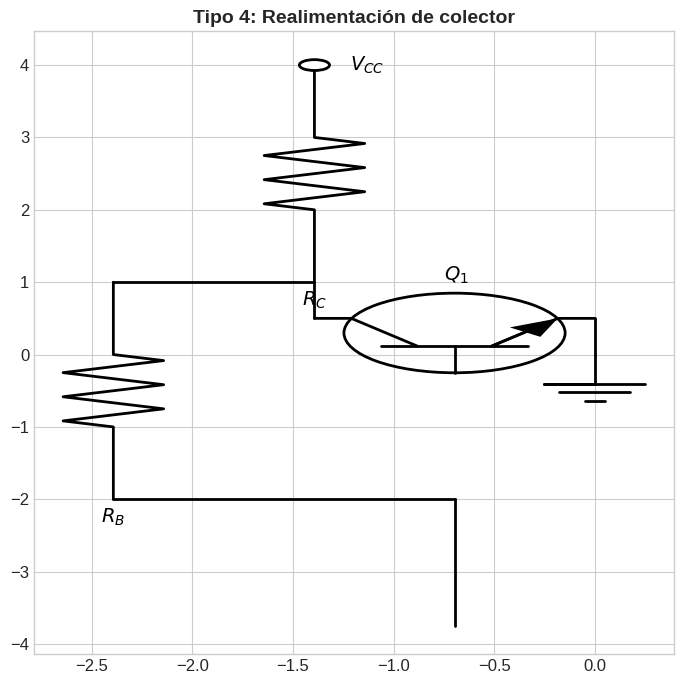

In [15]:
# Tipo 4: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title('Tipo 4: Realimentación de colector', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
d += elm.BjtNpn(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Line().at(bjt.collector).up().length(0.5)
col_point = d.here
d += elm.Resistor().up().label('$R_C$', loc='left')
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
d += elm.Line().at(col_point).left().length(1)
d += elm.Resistor().down().label('$R_B$', loc='left')
d += elm.Line().right().tox(bjt.base)
d += elm.Line().down().toy(bjt.base)
d.draw()
plt.tight_layout(); plt.show()

### 10.5 Tipo 5: Divisor de tensión ($R_1 + R_2 + R_C + R_E$)

El circuito **más estable** y **más usado**. Un divisor $R_1$-$R_2$ fija la tensión de base.

**Método: equivalente de Thévenin en la base:**

$$V_{TH} = V_{CC} \cdot \frac{R_2}{R_1 + R_2} \qquad R_{TH} = R_1 \| R_2 = \frac{R_1 \cdot R_2}{R_1 + R_2}$$

El circuito queda como un **Tipo 3** con $V_{TH}$ y $R_{TH}$:

$$\boxed{I_B = \frac{V_{TH} - V_{BE}}{R_{TH} + R_E(\beta+1)}} \qquad V_{CE} = V_{CC} - R_C \cdot I_C - R_E \cdot I_E$$

**Si $\beta$ es grande:** $I_C \approx \dfrac{V_{TH} - V_{BE}}{R_E}$ (ya no depende de $\beta$).

**Cómo afectan las resistencias:**
- **$R_1$ y $R_2$** fijan $V_{TH}$. Si $R_2/(R_1+R_2)$ es grande, $V_{TH}$ es alto y $I_C$ aumenta.
- **$R_E$ estabiliza**: cuanto mayor, más estable pero menos $V_{CE}$ disponible.
- **$R_C$ afecta solo a $V_{CE}$**: mayor $R_C \to$ menor $V_{CE}$, más riesgo de saturación.
- **Para máxima estabilidad**: elegir $R_{TH} \ll R_E \cdot \beta$.

#### Ejercicio resuelto: Tipo 5

**Datos:** $V_{CC} = 12$ V, $R_1 = 47$ k$\Omega$, $R_2 = 10$ k$\Omega$, $R_C = 2.2$ k$\Omega$, $R_E = 1$ k$\Omega$, $\beta = 200$

**Thévenin:**

$$V_{TH} = 12 \times \frac{10}{47+10} = 2.11\;\text{V} \qquad R_{TH} = \frac{47 \times 10}{47+10} = 8.25\;\text{k}\Omega$$

**Resolver:**

$$I_B = \frac{2.11 - 0.7}{8.25\text{k} + 1\text{k} \times 201} = \frac{1.41}{209\,250} = 6.72\;\mu\text{A}$$

$$I_C = 200 \times 6.72 = 1.34\;\text{mA} \qquad I_E = 201 \times 6.72 = 1.35\;\text{mA}$$

$$V_{CE} = 12 - 2.2\text{k} \times 1.34 - 1\text{k} \times 1.35 = 12 - 2.96 - 1.35 = 7.69\;\text{V}$$

$V_{CE} = 7.69$ V $> 0.2$ V $\to$ **ACTIVA.**

**Aproximación $\beta \to \infty$:** $I_C \approx (2.11 - 0.7)/1\text{k} = 1.41$ mA (error solo 5%).

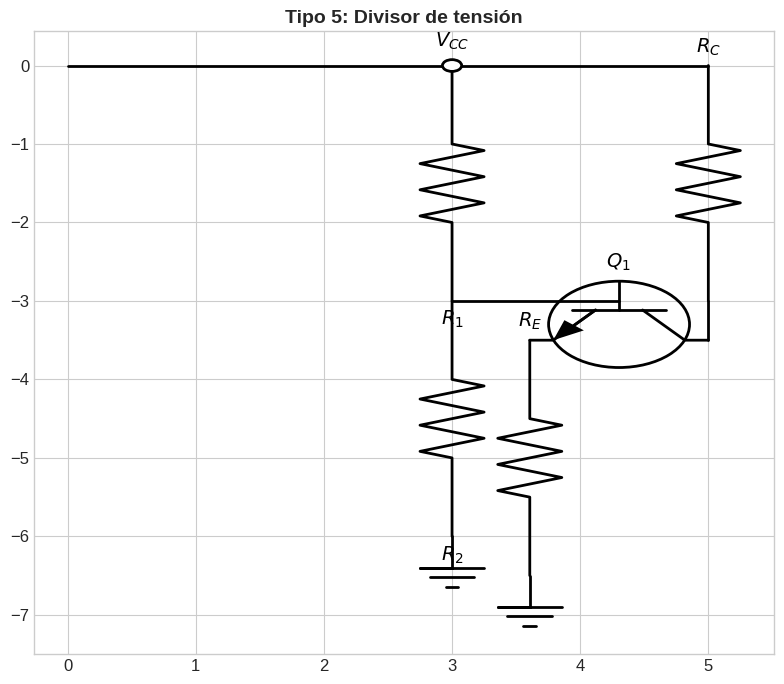

In [16]:
# Tipo 5: Diagrama
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Tipo 5: Divisor de tensión', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(3)
d += elm.Dot(open=True).label('$V_{CC}$', loc='top')
top = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label('$R_C$', loc='right')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label('$R_E$', loc='right')
d += elm.Ground()
d += elm.Resistor().at(top).down().length(3).label('$R_1$', loc='left')
mid = d.here
d += elm.Line().right().tox(bjt.base)
d += elm.Resistor().at(mid).down().length(3).label('$R_2$', loc='left')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 10.6 Tipo 6: Circuitos PNP

Cualquier topología anterior puede usarse con PNP. Las reglas:

1. $V_{CC}$ se conecta al **emisor** (referencia invertida)
2. Tensiones: $V_{EB}$ y $V_{EC}$ en lugar de $V_{BE}$ y $V_{CE}$
3. Las corrientes cambian de sentido
4. **Las fórmulas son idénticas en magnitud**

#### Ejercicio resuelto: PNP con divisor de tensión

**Datos:** $V_{CC} = 12$ V, $R_1 = 10$ k$\Omega$ (arriba), $R_2 = 47$ k$\Omega$ (abajo), $R_C = 2.2$ k$\Omega$, $R_E = 1$ k$\Omega$, $\beta = 100$

$$V_B = 12 \times \frac{47}{10+47} = 9.89\;\text{V} \qquad R_{TH} = \frac{10 \times 47}{10+47} = 8.25\;\text{k}\Omega$$

Diferencia emisor-base: $V_{CC} - V_B = 12 - 9.89 = 2.11$ V

$$I_B = \frac{V_{CC} - V_B - V_{EB}}{R_{TH} + R_E(\beta+1)} = \frac{2.11 - 0.7}{8.25\text{k} + 1\text{k} \times 101} = \frac{1.41}{109\,250} = 12.91\;\mu\text{A}$$

$$I_C = 100 \times 12.91 = 1.29\;\text{mA} \qquad V_{EC} = 12 - 1\text{k} \times 1.30 - 2.2\text{k} \times 1.29 = 7.86\;\text{V}$$

$V_{EC} = 7.86$ V $> 0.2$ V $\to$ **ACTIVA.**

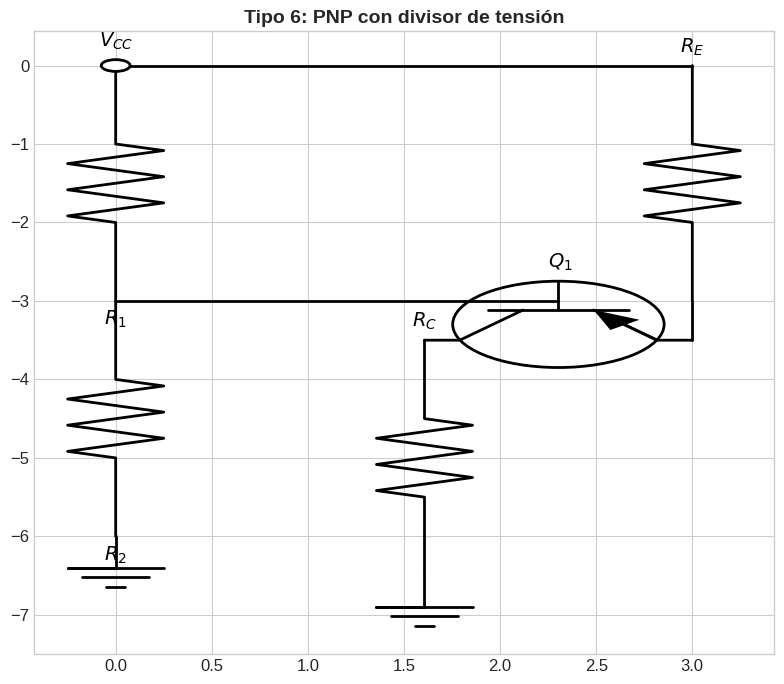

In [17]:
# Tipo 6: PNP con divisor
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Tipo 6: PNP con divisor de tensión', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}$', loc='top')
top = d.here
d += elm.Resistor().down().length(3).label('$R_1$', loc='left')
mid = d.here
d += elm.Resistor().down().length(3).label('$R_2$', loc='left')
d += elm.Ground()
d += elm.Line().at(top).right().length(3)
d += elm.Resistor().down().label('$R_E$', loc='right')
d += elm.Line().down().length(0.5)
d += elm.BjtPnp(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Line().at(mid).right().tox(bjt.base)
d += elm.Resistor().at(bjt.collector).down().label('$R_C$', loc='right')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

### 10.7 Tipo 7: Circuitos combinados

En exámenes aparecen combinaciones de los tipos anteriores. **La metodología es siempre la misma**: plantear KVL en las mallas, sustituir el modelo, resolver y verificar.

#### 7a: Dos fuentes + $R_E$

$$I_B = \frac{V_{BB} - V_{BE}}{R_B + R_E(\beta+1)} \qquad V_{CE} = V_{CC} - R_C \cdot I_C - R_E \cdot I_E$$

#### 7b: Realimentación de colector + $R_E$

$$I_B = \frac{V_{CC} - V_{BE}}{R_B + (R_C + R_E)(\beta+1)} \qquad V_{CE} = V_{CC} - R_C(I_C+I_B) - R_E \cdot I_E$$

#### Ejercicio resuelto: Tipo 7a (dos fuentes + $R_E$)

**Datos:** $V_{BB} = 4$ V, $V_{CC} = 15$ V, $R_B = 50$ k$\Omega$, $R_C = 2$ k$\Omega$, $R_E = 500\;\Omega$, $\beta = 80$

$$I_B = \frac{4 - 0.7}{50\text{k} + 500 \times 81} = \frac{3.3}{90\,500} = 36.46\;\mu\text{A}$$

$$I_C = 80 \times 36.46 = 2.92\;\text{mA} \qquad I_E = 81 \times 36.46 = 2.95\;\text{mA}$$

$$V_{CE} = 15 - 2\text{k} \times 2.92 - 500 \times 2.95 = 15 - 5.84 - 1.48 = 7.68\;\text{V}$$

$V_{CE} = 7.68$ V $> 0.2$ V $\to$ **ACTIVA.**

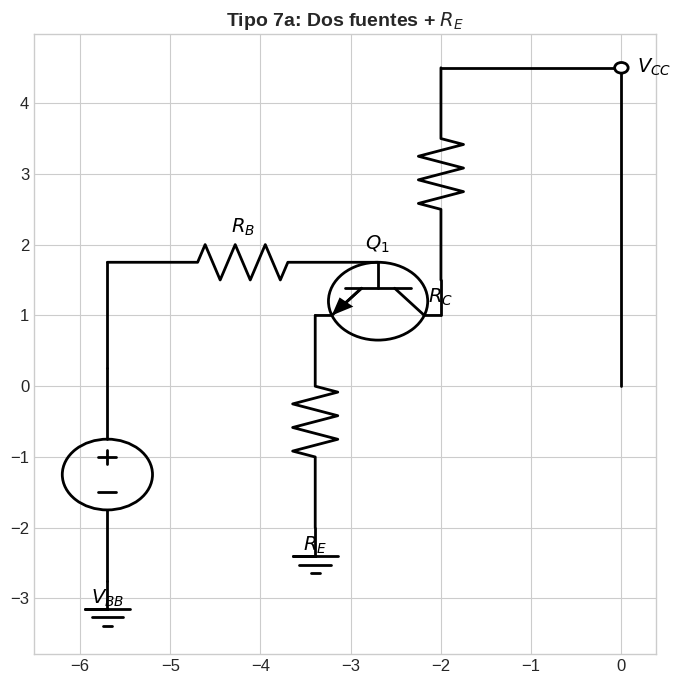

In [18]:
# Tipo 7a: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 7a: Dos fuentes + $R_E$', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(4.5)
d += elm.Dot(open=True).label('$V_{CC}$', loc='right')
top = d.here
d += elm.Line().left().length(2)
d += elm.Resistor().down().label('$R_C$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label('$R_E$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label('$R_B$', loc='top')
d += elm.Line().down().length(1.5)
d += elm.SourceV().down().label('$V_{BB}$', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

---
### 10.8 Ejercicios adicionales

#### Ejercicio: Divisor de tensión que entra en saturación

**Datos:** $V_{CC} = 10$ V, $R_1 = R_2 = 10$ k$\Omega$, $R_C = 5$ k$\Omega$, $R_E = 1$ k$\Omega$, $\beta = 150$

**Thévenin:** $V_{TH} = 5$ V, $R_{TH} = 5$ k$\Omega$

**Intento 1 (Activa):**

$$I_B = \frac{5 - 0.7}{5\text{k} + 1\text{k} \times 151} = \frac{4.3}{156\,000} = 27.56\;\mu\text{A}$$

$$I_C = 150 \times 27.56 = 4.13\;\text{mA} \qquad I_E = 151 \times 27.56 = 4.16\;\text{mA}$$

$$V_{CE} = 10 - 5\text{k} \times 4.13 - 1\text{k} \times 4.16 = 10 - 20.66 - 4.16 = -14.82\;\text{V}$$

$V_{CE}$ es **negativo** $\to$ imposible $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V

En saturación hay que resolver el sistema de dos mallas porque $I_C \neq \beta \cdot I_B$:

- Malla base: $V_{TH} = R_{TH} \cdot I_B + V_{BE_{sat}} + R_E \cdot (I_B + I_C)$
- Malla colector: $V_{CC} = R_C \cdot I_C + V_{CE_{sat}} + R_E \cdot (I_B + I_C)$

De la malla de colector: $I_C = \dfrac{V_{CC} - V_{CE_{sat}} - R_E \cdot I_B}{R_C + R_E} = \dfrac{10 - 0.2 - 1\text{k} \cdot I_B}{6\text{k}}$

Sustituyendo en la malla de base y resolviendo: $I_B = 440\;\mu\text{A}$, $I_C = 1.56$ mA.

Verificar: $I_C = 1.56$ mA $< \beta \cdot I_B = 150 \times 0.44 = 66$ mA $\to$ **SATURACIÓN confirmada.**

#### Ejercicio: Cálculo del $\beta$ mínimo para saturación

**Datos:** $V_{CC} = 5$ V, $R_B = 10$ k$\Omega$, $R_C = 1$ k$\Omega$ (polarización fija)

La corriente de base es fija: $I_B = \dfrac{5 - 0.7}{10\text{k}} = 0.43\;\text{mA}$

En el **límite** de saturación: $V_{CE} = V_{CE_{sat}} = 0.2$ V

$$I_{C_{lim}} = \frac{V_{CC} - V_{CE_{sat}}}{R_C} = \frac{5 - 0.2}{1\text{k}} = 4.8\;\text{mA}$$

$$\beta_{min} = \frac{I_{C_{lim}}}{I_B} = \frac{4.8}{0.43} = 11.2$$

| $\beta$ | $I_C = \beta \cdot I_B$ | $V_{CE}$ | Estado |
|---------|------------------------|----------|--------|
| 5 | 2.15 mA | 2.85 V | Activa |
| 10 | 4.30 mA | 0.70 V | Activa |
| **12** | **5.16 mA** | **-0.16 V** | **Saturación** |
| 50 | saturado | 0.2 V | Saturación |
| 100 | saturado | 0.2 V | Saturación |

**Para $\beta \geq 12$: el transistor entra en saturación.** Con $R_B$ tan baja y $R_C$ moderada, es fácil saturar.

### 10.9 Resumen: fórmula de $I_B$ según el tipo

| Tipo | Fórmula de $I_B$ | Qué ve la base |
|------|-------------------|----------------|
| 1. Pol. fija | $\dfrac{V_{CC} - V_{BE}}{R_B}$ | Solo $R_B$ |
| 2. Dos fuentes | $\dfrac{V_{BB} - V_{BE}}{R_B}$ | Solo $R_B$ |
| 3. Con $R_E$ | $\dfrac{V_{CC} - V_{BE}}{R_B + R_E(\beta+1)}$ | $R_B + R_E$ amplificada |
| 4. Realim. C | $\dfrac{V_{CC} - V_{BE}}{R_B + R_C(\beta+1)}$ | $R_B + R_C$ amplificada |
| 5. Divisor | $\dfrac{V_{TH} - V_{BE}}{R_{TH} + R_E(\beta+1)}$ | Thévenin + $R_E$ |
| 7b. Realim+$R_E$ | $\dfrac{V_{CC} - V_{BE}}{R_B + (R_C+R_E)(\beta+1)}$ | $R_B$ + ambas amplificadas |

**Patrón general:** siempre es $\dfrac{\text{tensión} - V_{BE}}{\text{resistencia total}}$. Las resistencias que están "después" de la base (entre emisor y tierra, o en la rama de realimentación) aparecen multiplicadas por $(\beta+1)$ porque por ellas circula $I_E$, no $I_B$.

### 10.10 Método universal: predecir el estado en 30 segundos

Para **cualquier** circuito BJT, el estado se determina comparando $\beta \cdot I_B$ con $I_{C_{max}}$:

| Tipo | Fórmula de $I_B$ (suponer activa) | $I_{C_{max}}$ | Si $\beta I_B > I_{C_{max}}$ |
|------|-----------------------------------|---------------|----------------------------|
| 1. Pol. fija | $\dfrac{V_{CC} - 0.7}{R_B}$ | $\dfrac{V_{CC}}{R_C}$ | Saturación |
| 2. Dos fuentes | $\dfrac{V_{BB} - 0.7}{R_B}$ | $\dfrac{V_{CC}}{R_C}$ | Saturación |
| 3. Con $R_E$ | $\dfrac{V_{CC} - 0.7}{R_B + R_E(\beta+1)}$ | $\dfrac{V_{CC}}{R_C + R_E}$ | Saturación |
| 4. Retroalim. C | $\dfrac{V_{CC} - 0.7}{R_B + R_C(\beta+1)}$ | $\dfrac{V_{CC}}{R_C}$ | Saturación |
| 5. Divisor | $\dfrac{V_{TH} - 0.7}{R_{TH} + R_E(\beta+1)}$ | $\dfrac{V_{CC}}{R_C + R_E}$ | Saturación |

**Procedimiento:**
1. Calcular $I_B$ con la fórmula de la segunda columna
2. Multiplicar por $\beta$
3. Comparar con $I_{C_{max}}$ de la tercera columna
4. Si $\beta \cdot I_B > I_{C_{max}}$: **saturación**. Si no: **activa**

#### ¿Por qué el Tipo 4 (retroalimentación) casi nunca satura?

Porque en su fórmula de $I_B$, el denominador contiene $R_C \cdot (\beta+1)$, que es un número **enorme**. Esto hace que $I_B$ sea muy pequeña, y por tanto $\beta \cdot I_B$ casi siempre es menor que $I_{C_{max}}$. La realimentación negativa se encarga de mantener el transistor en activa.

**Ejemplo:** $V_{CC}=10$ V, $R_B=200$ k$\Omega$, $R_C=2$ k$\Omega$, $\beta=150$

$$I_B = \frac{10 - 0.7}{200\text{k} + 2\text{k} \times 151} = 18.5\;\mu\text{A} \qquad \beta I_B = 2.78\;\text{mA} \qquad I_{C_{max}} = \frac{10}{2\text{k}} = 5\;\text{mA}$$

$2.78 < 5$ $\to$ **Activa.** Si fuera polarización fija con los mismos valores: $I_B = 50\;\mu$A, $\beta I_B = 7.5$ mA $> 5$ mA $\to$ saturaría.

#### El atajo $R_B/R_C$ vs $\beta$ y cuándo usarlo

| Circuito | ¿Funciona el atajo? | Por qué |
|----------|-------------------|---------|
| Pol. fija | Sí | $R_B$ ve tensión fija $V_{CC}$ |
| Con $R_E$ | Sí, con $(R_C+R_E)$ | $R_B$ ve tensión fija |
| Dos fuentes | Sí, ajustando por $V_{BB}/V_{CC}$ | Tensión fija |
| Divisor | Sí, con $R_{TH}/(R_C+R_E)$ | $V_{TH}$ es fija |
| **Retroalim. C** | **No** | $R_B$ ve $V_C$ que depende de $I_C$ |

**Regla**: si $R_B$ está conectada a un punto de **tensión fija**, el atajo vale. Si está conectada a un punto que **depende de $I_C$**, usar el método universal.

---
### 10.11 Ejercicios de saturación para cada tipo de circuito

En todos los ejercicios anteriores el transistor quedaba en **zona activa**. Pero en la práctica es muy habitual que con ciertos valores de componentes el transistor **sature**. El procedimiento es siempre:

1. **Suponer activa** ($V_{BE} = 0.7$ V) y calcular $I_B$, $I_C = \beta \cdot I_B$, $V_{CE}$
2. Si $V_{CE} < V_{CE_{sat}} = 0.2$ V (o negativo) $\to$ **la hipótesis falla**
3. **Cambiar a saturación**: $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V, y $I_C \neq \beta \cdot I_B$
4. Resolver las **dos mallas independientes** (base y colector) para obtener $I_B$ e $I_C$
5. **Verificar**: $I_C < \beta \cdot I_B$ $\to$ saturación confirmada

#### Ejercicio de saturación: Tipo 1

**Datos:** $V_{CC} = 12$ V, $R_B = 100$ k$\Omega$, $R_C = 3$ k$\Omega$, $\beta = 200$

**Intento 1 (Activa):** $V_{BE} = 0.7$ V

$$I_B = \frac{V_{CC} - V_{BE}}{R_B} = \frac{12 - 0.7}{100\text{k}\Omega} = 113\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 200 \times 113\;\mu\text{A} = 22.6\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C = 12 - 3\text{k} \times 22.6 = 12 - 67.8 = -55.8\;\text{V}$$

$V_{CE}$ es **negativo** $\to$ imposible $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V

En el Tipo 1 sin $R_E$, las dos mallas son **independientes**:

- **Malla base:** $V_{CC} = R_B \cdot I_B + V_{BE_{sat}}$

$$\boxed{I_B = \frac{V_{CC} - V_{BE_{sat}}}{R_B} = \frac{12 - 0.8}{100\text{k}} = 112\;\mu\text{A}}$$

- **Malla colector:** $V_{CC} = R_C \cdot I_C + V_{CE_{sat}}$

$$\boxed{I_C = \frac{V_{CC} - V_{CE_{sat}}}{R_C} = \frac{12 - 0.2}{3\text{k}} = 3.93\;\text{mA}}$$

**Verificación:** $I_C = 3.93$ mA $< \beta \cdot I_B = 200 \times 0.112 = 22.4$ mA $\to$ **SATURACIÓN confirmada.** ✓

In [ ]:
# Tipo 1 Saturación: Diagrama
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title(r'Tipo 1 Saturación: $R_B=100\,k\Omega$, $R_C=3\,k\Omega$', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(3)
d += elm.Dot(open=True).label('$V_{CC}=12$ V', loc='right')
top = d.here
d += elm.Line().left().length(3)
d += elm.Resistor().down().label(r'$R_C=3\,k\Omega$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Ground().at(bjt.emitter)
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=100\,k\Omega$', loc='top')
d += elm.Line().up().toy(top)
d += elm.Line().right().tox(top)
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio de saturación: Tipo 2

**Datos:** $V_{BB} = 5$ V, $V_{CC} = 8$ V, $R_B = 50$ k$\Omega$, $R_C = 2$ k$\Omega$, $\beta = 150$

**Intento 1 (Activa):** $V_{BE} = 0.7$ V

$$I_B = \frac{V_{BB} - V_{BE}}{R_B} = \frac{5 - 0.7}{50\text{k}} = 86\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 150 \times 86\;\mu\text{A} = 12.9\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C = 8 - 2\text{k} \times 12.9 = 8 - 25.8 = -17.8\;\text{V}$$

$V_{CE}$ es **negativo** $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V

Las mallas son independientes (no hay $R_E$ compartida):

- **Malla base:** $V_{BB} = R_B \cdot I_B + V_{BE_{sat}}$

$$\boxed{I_B = \frac{V_{BB} - V_{BE_{sat}}}{R_B} = \frac{5 - 0.8}{50\text{k}} = 84\;\mu\text{A}}$$

- **Malla colector:** $V_{CC} = R_C \cdot I_C + V_{CE_{sat}}$

$$\boxed{I_C = \frac{V_{CC} - V_{CE_{sat}}}{R_C} = \frac{8 - 0.2}{2\text{k}} = 3.9\;\text{mA}}$$

**Verificación:** $I_C = 3.9$ mA $< \beta \cdot I_B = 150 \times 0.084 = 12.6$ mA $\to$ **SATURACIÓN confirmada.** ✓

In [ ]:
# Tipo 2 Saturación: Diagrama
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title(r'Tipo 2 Saturación: $V_{BB}=5$ V, $R_C=2\,k\Omega$', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(3)
d += elm.Dot(open=True).label('$V_{CC}=8$ V', loc='right')
top_r = d.here
d += elm.Line().left().length(2)
d += elm.Resistor().down().label(r'$R_C=2\,k\Omega$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Ground().at(bjt.emitter)
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=50\,k\Omega$', loc='top')
d += elm.Line().down().length(1)
d += elm.SourceV().down().label('$V_{BB}=5$ V', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio de saturación: Tipo 3

**Datos:** $V_{CC} = 10$ V, $R_B = 50$ k$\Omega$, $R_C = 2$ k$\Omega$, $R_E = 500\;\Omega$, $\beta = 200$

**Intento 1 (Activa):** $V_{BE} = 0.7$ V

$$I_B = \frac{V_{CC} - V_{BE}}{R_B + R_E(\beta + 1)} = \frac{10 - 0.7}{50\text{k} + 500 \times 201} = \frac{9.3}{150\,500} = 61.8\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 200 \times 61.8\;\mu\text{A} = 12.36\;\text{mA}$$

$$I_E = (\beta + 1) \cdot I_B = 201 \times 61.8\;\mu\text{A} = 12.42\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C - R_E \cdot I_E = 10 - 2\text{k} \times 12.36 - 500 \times 12.42 = 10 - 24.72 - 6.21 = -20.93\;\text{V}$$

$V_{CE}$ es **negativo** $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V

Con $R_E$ las mallas están **acopladas** a través de $I_E = I_B + I_C$. Hay que resolver un sistema 2×2:

- **Malla base:** $V_{CC} = R_B \cdot I_B + V_{BE_{sat}} + R_E \cdot (I_B + I_C)$

$$10 = 50\text{k} \cdot I_B + 0.8 + 500 \cdot (I_B + I_C)$$

$$9.2 = 50{,}500 \cdot I_B + 500 \cdot I_C \quad \cdots (1)$$

- **Malla colector:** $V_{CC} = R_C \cdot I_C + V_{CE_{sat}} + R_E \cdot (I_B + I_C)$

$$10 = 2\text{k} \cdot I_C + 0.2 + 500 \cdot (I_B + I_C)$$

$$9.8 = 500 \cdot I_B + 2{,}500 \cdot I_C \quad \cdots (2)$$

**Resolviendo el sistema:**

De (2): $I_B = \dfrac{9.8 - 2{,}500 \cdot I_C}{500} = 19.6 \times 10^{-3} - 5 \cdot I_C$

Sustituyendo en (1):

$$9.2 = 50{,}500 \cdot (19.6 \times 10^{-3} - 5 \cdot I_C) + 500 \cdot I_C$$

$$9.2 = 989.8 - 252{,}500 \cdot I_C + 500 \cdot I_C$$

$$252{,}000 \cdot I_C = 980.6$$

$$\boxed{I_C = \frac{980.6}{252{,}000} = 3.89\;\text{mA}}$$

$$\boxed{I_B = 19.6 \times 10^{-3} - 5 \times 3.89 \times 10^{-3} = 0.15 \times 10^{-3} = 150\;\mu\text{A}}$$

**Verificación:** $I_C = 3.89$ mA $< \beta \cdot I_B = 200 \times 0.150 = 30$ mA $\to$ **SATURACIÓN confirmada.** ✓

> **Nota:** Cuando hay $R_E$, la saturación siempre requiere resolver el sistema 2×2. No se puede obtener $I_C$ directamente de una sola malla.

In [ ]:
# Tipo 3 Saturación: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 3 Saturación: Con $R_E$', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(4.5)
d += elm.Dot(open=True).label('$V_{CC}=10$ V', loc='right')
top = d.here
d += elm.Line().left().length(2)
d += elm.Resistor().down().label(r'$R_C=2\,k\Omega$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label(r'$R_E=500\,\Omega$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=50\,k\Omega$', loc='top')
d += elm.Line().up().toy(top)
d += elm.Line().right().tox(top)
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio de saturación: Tipo 4

**Datos:** $V_{CC} = 5$ V, $R_B = 50$ k$\Omega$, $R_C = 2$ k$\Omega$, $\beta = 200$

> **Nota:** La realimentación de colector **dificulta** la saturación porque al bajar $V_{CE}$, baja la tensión disponible para $R_B$ y se reduce $I_B$. Pero con $\beta$ alto y $R_B$ pequeño, puede ocurrir.

**Intento 1 (Activa):** $V_{BE} = 0.7$ V

En Tipo 4: $R_B$ va de colector a base, por lo que la malla de base pasa por $R_C$:

$$I_B = \frac{V_{CC} - V_{BE}}{R_B + R_C(\beta + 1)} = \frac{5 - 0.7}{50\text{k} + 2\text{k} \times 201} = \frac{4.3}{452\text{k}} = 9.51\;\mu\text{A}$$

$$I_C = 200 \times 9.51 = 1.90\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot (I_C + I_B) = 5 - 2\text{k} \times (1.90 + 0.00951) = 5 - 3.82 = 1.18\;\text{V}$$

$V_{CE} = 1.18$ V $> 0.2$ V $\to$ en este caso **ACTIVA confirmada**.

Veamos qué pasa si reducimos $R_B$:

**Nuevo dato:** $R_B = 10$ k$\Omega$ (todo lo demás igual)

$$I_B = \frac{5 - 0.7}{10\text{k} + 2\text{k} \times 201} = \frac{4.3}{412\text{k}} = 10.44\;\mu\text{A}$$

$$I_C = 200 \times 10.44 = 2.088\;\text{mA}$$

$$V_{CE} = 5 - 2\text{k} \times (2.088 + 0.01044) = 5 - 4.20 = 0.80\;\text{V}$$

Todavía activa. Probemos con $R_B = 5$ k$\Omega$:

$$I_B = \frac{5 - 0.7}{5\text{k} + 402\text{k}} = \frac{4.3}{407\text{k}} = 10.56\;\mu\text{A}$$

La realimentación estabiliza mucho. Para forzar saturación usemos $R_C = 4$ k$\Omega$, $R_B = 10$ k$\Omega$:

$$I_B = \frac{5 - 0.7}{10\text{k} + 4\text{k} \times 201} = \frac{4.3}{814\text{k}} = 5.28\;\mu\text{A}$$

$$I_C = 200 \times 5.28 = 1.056\;\text{mA}$$

$$V_{CE} = 5 - 4\text{k} \times (1.056 + 0.00528) = 5 - 4.25 = 0.75\;\text{V}$$

Sigue activa. Esto demuestra que **el Tipo 4 es muy resistente a la saturación**, que es justamente su ventaja. Para un ejercicio de saturación genuino con este tipo usaremos valores extremos:

**Datos forzados:** $V_{CC} = 5$ V, $R_B = 5$ k$\Omega$, $R_C = 10$ k$\Omega$, $\beta = 200$

$$I_B = \frac{5 - 0.7}{5\text{k} + 10\text{k} \times 201} = \frac{4.3}{2{,}015\text{k}} = 2.13\;\mu\text{A}$$

$$I_C = 200 \times 2.13 = 0.427\;\text{mA} \qquad V_{CE} = 5 - 10\text{k} \times 0.429 = 0.71\;\text{V}$$

Aún activa. **Conclusión para el examen:** el Tipo 4 prácticamente **nunca satura** en condiciones razonables. Si te dan un Tipo 4 en el examen, lo más probable es que esté en activa.

In [ ]:
# Tipo 4 Saturación: Diagrama (caso de análisis)
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 4: Realimentación de colector ($R_B$ pequeño)', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
d += elm.BjtNpn(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Line().at(bjt.collector).up().length(0.5)
col_point = d.here
d += elm.Resistor().up().label(r'$R_C=2\,k\Omega$', loc='left')
d += elm.Dot(open=True).label('$V_{CC}=5$ V', loc='right')
d += elm.Line().at(col_point).left().length(1)
d += elm.Resistor().down().label(r'$R_B=50\,k\Omega$', loc='left')
d += elm.Line().right().tox(bjt.base)
d += elm.Line().down().toy(bjt.base)
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio de saturación: Tipo 5

**Datos:** $V_{CC} = 10$ V, $R_1 = R_2 = 10$ k$\Omega$, $R_C = 5$ k$\Omega$, $R_E = 1$ k$\Omega$, $\beta = 150$

**Thévenin en la base:**

$$V_{TH} = V_{CC} \cdot \frac{R_2}{R_1 + R_2} = 10 \times \frac{10\text{k}}{20\text{k}} = 5\;\text{V}$$

$$R_{TH} = R_1 \| R_2 = \frac{10\text{k} \times 10\text{k}}{20\text{k}} = 5\;\text{k}\Omega$$

**Intento 1 (Activa):** $V_{BE} = 0.7$ V

$$I_B = \frac{V_{TH} - V_{BE}}{R_{TH} + R_E(\beta + 1)} = \frac{5 - 0.7}{5\text{k} + 1\text{k} \times 151} = \frac{4.3}{156\text{k}} = 27.56\;\mu\text{A}$$

$$I_C = 150 \times 27.56 = 4.13\;\text{mA} \qquad I_E = 151 \times 27.56 = 4.16\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C - R_E \cdot I_E = 10 - 5\text{k} \times 4.13 - 1\text{k} \times 4.16 = 10 - 20.66 - 4.16 = -14.82\;\text{V}$$

$V_{CE}$ es **negativo** $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V

Usando el equivalente Thévenin, el sistema 2×2 es:

- **Malla base:** $V_{TH} = R_{TH} \cdot I_B + V_{BE_{sat}} + R_E \cdot (I_B + I_C)$

$$5 = 5\text{k} \cdot I_B + 0.8 + 1\text{k} \cdot (I_B + I_C)$$

$$4.2 = 6\text{k} \cdot I_B + 1\text{k} \cdot I_C \quad \cdots (1)$$

- **Malla colector:** $V_{CC} = R_C \cdot I_C + V_{CE_{sat}} + R_E \cdot (I_B + I_C)$

$$10 = 5\text{k} \cdot I_C + 0.2 + 1\text{k} \cdot (I_B + I_C)$$

$$9.8 = 1\text{k} \cdot I_B + 6\text{k} \cdot I_C \quad \cdots (2)$$

**Resolviendo el sistema:**

De (1): $I_B = \dfrac{4.2 - 1\text{k} \cdot I_C}{6\text{k}} = 0.7 \times 10^{-3} - \dfrac{I_C}{6}$

Sustituyendo en (2):

$$9.8 = 1\text{k} \cdot \left(0.7 \times 10^{-3} - \frac{I_C}{6}\right) + 6\text{k} \cdot I_C$$

$$9.8 = 0.7 - \frac{1\text{k}}{6} \cdot I_C + 6\text{k} \cdot I_C$$

$$9.1 = \left(6\text{k} - \frac{1\text{k}}{6}\right) \cdot I_C = \frac{35\text{k}}{6} \cdot I_C$$

$$\boxed{I_C = \frac{9.1 \times 6}{35\text{k}} = \frac{54.6}{35{,}000} = 1.56\;\text{mA}}$$

$$\boxed{I_B = 0.7 \times 10^{-3} - \frac{1.56 \times 10^{-3}}{6} = 0.7 \times 10^{-3} - 0.26 \times 10^{-3} = 0.44 \times 10^{-3} = 440\;\mu\text{A}}$$

**Verificación:** $I_C = 1.56$ mA $< \beta \cdot I_B = 150 \times 0.44 = 66$ mA $\to$ **SATURACIÓN confirmada.** ✓

In [ ]:
# Tipo 5 Saturación: Diagrama
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(r'Tipo 5 Saturación: Divisor de tensión ($R_1=R_2=10\,k\Omega$)', fontsize=12, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(3)
d += elm.Dot(open=True).label('$V_{CC}=10$ V', loc='top')
top = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label(r'$R_C=5\,k\Omega$', loc='right')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label(r'$R_E=1\,k\Omega$', loc='right')
d += elm.Ground()
d += elm.Resistor().at(top).down().length(3).label(r'$R_1=10\,k\Omega$', loc='left')
mid = d.here
d += elm.Line().right().tox(bjt.base)
d += elm.Resistor().at(mid).down().length(3).label(r'$R_2=10\,k\Omega$', loc='left')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio de saturación: Tipo 7 (dos fuentes + $R_E$)

**Datos:** $V_{BB} = 6$ V, $V_{CC} = 10$ V, $R_B = 30$ k$\Omega$, $R_C = 2$ k$\Omega$, $R_E = 500\;\Omega$, $\beta = 150$

**Intento 1 (Activa):** $V_{BE} = 0.7$ V

$$I_B = \frac{V_{BB} - V_{BE}}{R_B + R_E(\beta + 1)} = \frac{6 - 0.7}{30\text{k} + 500 \times 151} = \frac{5.3}{105{,}500} = 50.24\;\mu\text{A}$$

$$I_C = 150 \times 50.24 = 7.54\;\text{mA} \qquad I_E = 151 \times 50.24 = 7.59\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C - R_E \cdot I_E = 10 - 2\text{k} \times 7.54 - 500 \times 7.59 = 10 - 15.08 - 3.79 = -8.87\;\text{V}$$

$V_{CE}$ es **negativo** $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V

Sistema 2×2 con $I_E = I_B + I_C$:

- **Malla base:** $V_{BB} = R_B \cdot I_B + V_{BE_{sat}} + R_E \cdot (I_B + I_C)$

$$6 = 30\text{k} \cdot I_B + 0.8 + 500 \cdot (I_B + I_C)$$

$$5.2 = 30{,}500 \cdot I_B + 500 \cdot I_C \quad \cdots (1)$$

- **Malla colector:** $V_{CC} = R_C \cdot I_C + V_{CE_{sat}} + R_E \cdot (I_B + I_C)$

$$10 = 2\text{k} \cdot I_C + 0.2 + 500 \cdot (I_B + I_C)$$

$$9.8 = 500 \cdot I_B + 2{,}500 \cdot I_C \quad \cdots (2)$$

**Resolviendo el sistema:**

De (2): $I_B = \dfrac{9.8 - 2{,}500 \cdot I_C}{500} = 19.6 \times 10^{-3} - 5 \cdot I_C$

Sustituyendo en (1):

$$5.2 = 30{,}500 \cdot (19.6 \times 10^{-3} - 5 \cdot I_C) + 500 \cdot I_C$$

$$5.2 = 597.8 - 152{,}500 \cdot I_C + 500 \cdot I_C$$

$$152{,}000 \cdot I_C = 592.6$$

$$\boxed{I_C = \frac{592.6}{152{,}000} = 3.90\;\text{mA}}$$

$$\boxed{I_B = 19.6 \times 10^{-3} - 5 \times 3.90 \times 10^{-3} = 19.6 \times 10^{-3} - 19.5 \times 10^{-3} = 0.1 \times 10^{-3} = 100\;\mu\text{A}}$$

$I_E = I_B + I_C = 0.1 + 3.9 = 4.0$ mA

**Verificación:** $I_C = 3.90$ mA $< \beta \cdot I_B = 150 \times 0.1 = 15$ mA $\to$ **SATURACIÓN confirmada.** ✓

In [ ]:
# Tipo 7 Saturación: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'Tipo 7 Saturación: Dos fuentes + $R_E$', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().up().length(4.5)
d += elm.Dot(open=True).label('$V_{CC}=10$ V', loc='right')
top = d.here
d += elm.Line().left().length(2)
d += elm.Resistor().down().label(r'$R_C=2\,k\Omega$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('collector').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label(r'$R_E=500\,\Omega$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=30\,k\Omega$', loc='top')
d += elm.Line().down().length(1.5)
d += elm.SourceV().down().label('$V_{BB}=6$ V', loc='left').reverse()
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

---
### 10.12 Ejercicios con transistor PNP para cada tipo de circuito

En un transistor **PNP**, las corrientes y tensiones se invierten respecto al NPN:

- $V_{EB} = 0.7$ V (activa) o $0.8$ V (saturación) — el **emisor** es más positivo que la base
- $V_{EC} = V_{CC} - R_C \cdot I_C$ (en vez de $V_{CE}$)
- $V_{EC_{sat}} = 0.2$ V
- Las corrientes **entran** por el emisor y **salen** por base y colector
- $V_{CC}$ se conecta al **emisor** (arriba) y $R_C$ va al **colector** (abajo, hacia GND)

Las fórmulas de $I_B$ son **idénticas** a las del NPN correspondiente, sustituyendo $V_{BE}$ por $V_{EB}$.

#### Ejercicio PNP: Tipo 1

**Datos:** $V_{CC} = 12$ V, $R_B = 240$ k$\Omega$, $R_C = 2.2$ k$\Omega$, $\beta = 100$

**Paso 1-2:** Suponer Activa ($V_{EB} = 0.7$ V)

**Paso 3-4:** La base se conecta a GND a través de $R_B$. La corriente de base sale por la base hacia GND:

$$I_B = \frac{V_{CC} - V_{EB}}{R_B} = \frac{12 - 0.7}{240\text{k}\Omega} = 47.08\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 47.08 = 4.71\;\text{mA}$$

$$V_{EC} = V_{CC} - R_C \cdot I_C = 12 - 2.2\text{k} \times 4.71 = 12 - 10.36 = 1.64\;\text{V}$$

**Paso 5:** $V_{EC} = 1.64$ V $> 0.2$ V $\to$ **ACTIVA confirmada.**

In [ ]:
# PNP Tipo 1: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title('PNP Tipo 1: Polarización fija', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}=12$ V', loc='top')
top = d.here
d += elm.Line().down().length(0.5)
d += elm.BjtPnp(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.collector).down().label(r'$R_C=2.2\,k\Omega$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=240\,k\Omega$', loc='top')
d += elm.Line().down().length(2)
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio PNP: Tipo 2

**Datos:** $V_{CC} = 10$ V, $V_{BB} = 4$ V, $R_B = 100$ k$\Omega$, $R_C = 1.5$ k$\Omega$, $\beta = 80$

**Paso 1-2:** Suponer Activa ($V_{EB} = 0.7$ V)

La fuente $V_{BB}$ polariza la base. La corriente de base va de la base hacia $V_{BB}$:

$$I_B = \frac{V_{CC} - V_{EB} - V_{BB}}{R_B} = \frac{10 - 0.7 - 4}{100\text{k}} = \frac{5.3}{100\text{k}} = 53\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 80 \times 53 = 4.24\;\text{mA}$$

$$V_{EC} = V_{CC} - R_C \cdot I_C = 10 - 1.5\text{k} \times 4.24 = 10 - 6.36 = 3.64\;\text{V}$$

**Paso 5:** $V_{EC} = 3.64$ V $> 0.2$ V $\to$ **ACTIVA confirmada.**

In [ ]:
# PNP Tipo 2: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title('PNP Tipo 2: Dos fuentes', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}=10$ V', loc='top')
top = d.here
d += elm.Line().down().length(0.5)
d += elm.BjtPnp(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.collector).down().label(r'$R_C=1.5\,k\Omega$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=100\,k\Omega$', loc='top')
d += elm.Line().down().length(1)
d += elm.SourceV().down().label('$V_{BB}=4$ V', loc='left')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio PNP: Tipo 3 (con $R_E$)

**Datos:** $V_{CC} = 12$ V, $R_B = 200$ k$\Omega$, $R_C = 1$ k$\Omega$, $R_E = 500\;\Omega$, $\beta = 100$

**Paso 1-2:** Suponer Activa ($V_{EB} = 0.7$ V)

En el PNP Tipo 3, $R_E$ va del emisor (arriba) a $V_{CC}$ y $R_C$ va del colector a GND. La malla base:

$$I_B = \frac{V_{CC} - V_{EB}}{R_B + R_E(\beta + 1)} = \frac{12 - 0.7}{200\text{k} + 500 \times 101} = \frac{11.3}{250{,}500} = 45.11\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 45.11 = 4.51\;\text{mA}$$

$$I_E = (\beta + 1) \cdot I_B = 101 \times 45.11 = 4.56\;\text{mA}$$

$$V_{EC} = V_{CC} - R_E \cdot I_E - R_C \cdot I_C = 12 - 500 \times 4.56 - 1\text{k} \times 4.51 = 12 - 2.28 - 4.51 = 5.21\;\text{V}$$

**Paso 5:** $V_{EC} = 5.21$ V $> 0.2$ V $\to$ **ACTIVA confirmada.**

In [ ]:
# PNP Tipo 3: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title(r'PNP Tipo 3: Con $R_E$', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}=12$ V', loc='top')
top = d.here
d += elm.Resistor().down().length(2).label(r'$R_E=500\,\Omega$', loc='left')
d += elm.Line().down().length(0.5)
d += elm.BjtPnp(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.collector).down().label(r'$R_C=1\,k\Omega$', loc='left')
d += elm.Ground()
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B=200\,k\Omega$', loc='top')
d += elm.Line().up().toy(top)
d += elm.Line().right().tox(top)
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio PNP: Tipo 4 (realimentación de colector)

**Datos:** $V_{CC} = 10$ V, $R_B = 300$ k$\Omega$, $R_C = 2$ k$\Omega$, $\beta = 100$

En el PNP Tipo 4, $R_B$ conecta el **colector** con la **base** (realimentación). $V_{CC}$ va al emisor directamente y $R_C$ va del colector a GND.

**Paso 1-2:** Suponer Activa ($V_{EB} = 0.7$ V)

La malla pasa por $R_C$ (donde cae $I_C + I_B$) y luego $R_B$ (donde cae $I_B$):

$$I_B = \frac{V_{CC} - V_{EB}}{R_B + R_C(\beta + 1)} = \frac{10 - 0.7}{300\text{k} + 2\text{k} \times 101} = \frac{9.3}{502\text{k}} = 18.53\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 18.53 = 1.85\;\text{mA}$$

$$V_{EC} = V_{CC} - R_C \cdot (I_C + I_B) = 10 - 2\text{k} \times (1.85 + 0.01853) = 10 - 3.74 = 6.26\;\text{V}$$

**Paso 5:** $V_{EC} = 6.26$ V $> 0.2$ V $\to$ **ACTIVA confirmada.**

In [ ]:
# PNP Tipo 4: Diagrama
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title('PNP Tipo 4: Realimentación de colector', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}=10$ V', loc='top')
top = d.here
d += elm.Line().down().length(0.5)
d += elm.BjtPnp(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Line().at(bjt.collector).down().length(0.5)
col_point = d.here
d += elm.Resistor().down().label(r'$R_C=2\,k\Omega$', loc='left')
d += elm.Ground()
d += elm.Line().at(col_point).left().length(1)
d += elm.Resistor().up().label(r'$R_B=300\,k\Omega$', loc='left')
d += elm.Line().right().tox(bjt.base)
d += elm.Line().down().toy(bjt.base)
d.draw()
plt.tight_layout(); plt.show()

#### Ejercicio PNP: Tipo 5 (divisor de tensión)

**Datos:** $V_{CC} = 12$ V, $R_1 = 10$ k$\Omega$ (inferior, a GND), $R_2 = 47$ k$\Omega$ (superior, a $V_{CC}$), $R_C = 2.2$ k$\Omega$, $R_E = 1$ k$\Omega$, $\beta = 100$

> **Nota PNP:** En el divisor PNP, $R_2$ (la de arriba, conectada a $V_{CC}$) y $R_1$ (la de abajo, a GND). La tensión en la base es:

$$V_B = V_{CC} \cdot \frac{R_1}{R_1 + R_2} = 12 \times \frac{10\text{k}}{57\text{k}} = 2.11\;\text{V}$$

**Thévenin:**

$$R_{TH} = R_1 \| R_2 = \frac{10\text{k} \times 47\text{k}}{57\text{k}} = 8.25\;\text{k}\Omega$$

**Paso 1-2:** Suponer Activa ($V_{EB} = 0.7$ V)

El emisor está a $V_{CC} - R_E \cdot I_E$. La tensión $V_{EB} = V_E - V_B$, donde $V_E = V_{CC} - R_E \cdot I_E$:

$$V_{EB} = (V_{CC} - R_E \cdot I_E) - V_B = 0.7\;\text{V}$$

Usando Thévenin desde la base:

$$I_B = \frac{V_{CC} - V_{EB} - V_B \cdot \frac{R_2}{R_1+R_2} \cdot \frac{R_1+R_2}{R_1}}{R_{TH} + ... }$$

Forma más directa: la caída desde $V_{CC}$ hasta la base pasando por $R_E$ y la unión EB:

$$V_{CC} - R_E \cdot I_E - V_{EB} = V_B$$

$$12 - 1\text{k} \cdot I_E - 0.7 = 2.11$$

$$I_E = \frac{12 - 0.7 - 2.11}{1\text{k}} = \frac{9.19}{1\text{k}} = 9.19\;\text{mA}$$

Pero esto ignora la corriente del divisor. Usando el **método Thévenin completo** para PNP:

La tensión Thévenin vista desde la base hacia $V_{CC}$ por el emisor:

$$I_B = \frac{V_{CC} - V_{EB} - V_{TH}}{R_E(\beta+1) + R_{TH}} = \frac{12 - 0.7 - 2.11}{1\text{k} \times 101 + 8.25\text{k}} = \frac{9.19}{109{,}250} = 84.12\;\mu\text{A}$$

$$I_C = 100 \times 84.12 = 8.41\;\text{mA}$$

$$I_E = 101 \times 84.12 = 8.50\;\text{mA}$$

$$V_{EC} = V_{CC} - R_E \cdot I_E - R_C \cdot I_C = 12 - 1\text{k} \times 8.50 - 2.2\text{k} \times 8.41 = 12 - 8.50 - 18.50 = -15.0\;\text{V}$$

$V_{EC}$ es **negativo** $\to$ **la hipótesis de activa falla**.

**Intento 2 (Saturación):** $V_{EB} = 0.8$ V, $V_{EC} = 0.2$ V

Sistema 2×2:

- **Malla base (emisor-base):** $V_{CC} - V_{TH} = R_E \cdot (I_B + I_C) + V_{EB_{sat}} + R_{TH} \cdot I_B$

$$12 - 2.11 = 1\text{k} \cdot (I_B + I_C) + 0.8 + 8.25\text{k} \cdot I_B$$

$$9.09 = 9.25\text{k} \cdot I_B + 1\text{k} \cdot I_C \quad \cdots (1)$$

- **Malla colector:** $V_{CC} = R_E \cdot (I_B + I_C) + V_{EC_{sat}} + R_C \cdot I_C$

$$12 = 1\text{k} \cdot (I_B + I_C) + 0.2 + 2.2\text{k} \cdot I_C$$

$$11.8 = 1\text{k} \cdot I_B + 3.2\text{k} \cdot I_C \quad \cdots (2)$$

De (2): $I_B = \dfrac{11.8 - 3.2\text{k} \cdot I_C}{1\text{k}} = 11.8 \times 10^{-3} - 3.2 \cdot I_C$

Sustituyendo en (1):

$$9.09 = 9.25\text{k} \cdot (11.8 \times 10^{-3} - 3.2 \cdot I_C) + 1\text{k} \cdot I_C$$

$$9.09 = 109.15 - 29{,}600 \cdot I_C + 1\text{k} \cdot I_C$$

$$28{,}600 \cdot I_C = 100.06$$

$$\boxed{I_C = \frac{100.06}{28{,}600} = 3.50\;\text{mA}}$$

$$\boxed{I_B = 11.8 \times 10^{-3} - 3.2 \times 3.50 \times 10^{-3} = 11.8 \times 10^{-3} - 11.2 \times 10^{-3} = 0.6 \times 10^{-3} = 600\;\mu\text{A}}$$

**Verificación:** $I_C = 3.50$ mA $< \beta \cdot I_B = 100 \times 0.6 = 60$ mA $\to$ **SATURACIÓN confirmada.** ✓

In [ ]:
# PNP Tipo 5: Diagrama
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(r'PNP Tipo 5: Divisor de tensión', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label('$V_{CC}=12$ V', loc='top')
top = d.here
d += elm.Resistor().down().length(3).label(r'$R_2=47\,k\Omega$', loc='left')
mid = d.here
d += elm.Resistor().down().length(3).label(r'$R_1=10\,k\Omega$', loc='left')
d += elm.Ground()
d += elm.Line().at(top).right().length(3)
d += elm.Resistor().down().label(r'$R_E=1\,k\Omega$', loc='right')
d += elm.Line().down().length(0.5)
d += elm.BjtPnp(circle=True).anchor('emitter').label('$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Line().at(mid).right().tox(bjt.base)
d += elm.Resistor().at(bjt.collector).down().label(r'$R_C=2.2\,k\Omega$', loc='right')
d += elm.Ground()
d.draw()
plt.tight_layout(); plt.show()

---
## 11. Resumen y conclusiones

1. **El BJT es una fuente de corriente controlada por corriente**: $I_C = \beta \cdot I_B$

2. **Tres zonas**: Corte ($I_B = I_C = 0$), Activa ($I_C = \beta I_B$), Saturación ($V_{CE} = V_{CEsat}$, $I_C < \beta I_B$)

3. **Modelos linealizados** permiten resolver circuitos sustituyendo el transistor por fuentes

4. **Metodología**: suponer estado $\to$ resolver $\to$ verificar $\to$ repetir si falla

5. **NPN vs PNP**: mismas ecuaciones, cambian $V_{BE} \leftrightarrow V_{EB}$ y $V_{CE} \leftrightarrow V_{EC}$

6. **$R_E$ estabiliza** el punto de operación frente a variaciones de $\beta$

7. **Divisor de tensión** es el circuito más estable: $I_C \approx (V_{TH} - V_{BE})/R_E$

| Fórmula clave | Uso |
|---------------|-----|
| $I_C = \beta \cdot I_B$ | Relación fundamental en activa |
| $I_E = (\beta + 1) \cdot I_B$ | Kirchhoff en el transistor |
| $I_C = -V_{CE}/R_C + V_{CC}/R_C$ | Recta de carga |
| $I_B = (V_1 - V_{BE})/R_B$ | Malla de base simple |
| $I_B = (V_1 - V_{BE})/(R_B + R_E(\beta+1))$ | Malla de base con $R_E$ |